In [2]:
#六因子模型，此處為六因子內部構造
# Momentum: 0.3*Z(3M Return) + 0.3*Z(6M Return) + 0.4*Z(12-1M Return)
# Value: 0.3*Z(FCF Yield) + 0.3*Z(Earnings Yield) + 0.4*Z(EBITDA/EV)
# Quality: 0.35*Z(ROIC) + 0.25*Z(Operating Margin) + 0.20*Z(FCF Margin) - 0.20*Z(Net Debt/EBITDA)
# Growth: 0.4*Z(3Y Revenue CAGR) + 0.4*Z(3Y EPS CAGR) + 0.2*Z(3Y FCF CAGR)
# Low Volatility: -0.6*Z(60D Volatility) - 0.4*Z(252D Volatility)
# Liquidity: 0.7*Z(log(20D ADV)) + 0.3*Z(log(60D ADV))

In [3]:
# ============================================================
# CONTROL ROOM
# ============================================================

import numpy as np
import pandas as pd
import yfinance as yf

from scipy.optimize import minimize

import matplotlib.pyplot as plt
import seaborn as sns
# ----- Factor Weights -----
FACTOR_WEIGHTS = {
    "momentum": 0.20,
    "value": 0.15,
    "quality": 0.20,
    "growth": 0.20,
    "low_volatility": 0.15,
    "liquidity": 0.10
}

assert abs(sum(FACTOR_WEIGHTS.values()) - 1.0) < 1e-8

# ----- Stock Selection -----
TOP_N = 25

# ----- Rebalancing -----
REBALANCE_FREQUENCY = "monthly"

# ----- Market Universe -----
UNIVERSE = "NASDAQ_100"

# ----- Research Period -----
START_DATE = "2018-01-01"
END_DATE = "2026-01-01"

# ----- Portfolio Constraints -----
MAX_WEIGHT = 0.10
MIN_WEIGHT = 0.00

# ----- Transaction Cost -----
TRANSACTION_COST = 0.001

# ----- Benchmark -----
BENCHMARK_TICKER = "QQQ"

# ----- Risk-Free Rate -----
RISK_FREE_RATE = 0.04

In [4]:
#環境插件測試用
import index_constitution as ic

print(ic.list_indices())

['csi300', 'csi500', 'sp500', 'nasdaq100', 'dow30']


In [5]:
# ============================================================
# 4. Get Historical Nasdaq-100 Constituents
# ============================================================

import index_constitution as ic


def get_nasdaq100_constituents(date):
    """
    Get Nasdaq-100 constituent securities as of a specific date.
    """

    df = ic.constituents_at("nasdaq100", date)

    date = pd.Timestamp(date)

    active = df[
        (pd.to_datetime(df["opt-in"]) <= date) &
        (
            df["opt-out"].isna() |
            (pd.to_datetime(df["opt-out"]) > date)
        )
    ]

    return sorted(active["symbol"].tolist())


# Test
TICKERS = get_nasdaq100_constituents("2020-01-31")

print(f"Number of securities in universe: {len(TICKERS)}")
print(TICKERS)

Number of securities in universe: 103
['AAL', 'AAPL', 'ADBE', 'ADI', 'ADP', 'ADSK', 'ALGN', 'ALXN', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANSS', 'ASML', 'ATVI', 'AVGO', 'BIDU', 'BIIB', 'BKNG', 'BMRN', 'CDNS', 'CDW', 'CERN', 'CHKP', 'CHTR', 'CMCSA', 'COST', 'CPRT', 'CSCO', 'CSGP', 'CSX', 'CTAS', 'CTSH', 'CTXS', 'DLTR', 'EA', 'EBAY', 'EXC', 'EXPE', 'FAST', 'FISV', 'FOX', 'FOXA', 'GILD', 'GOOG', 'GOOGL', 'IDXX', 'ILMN', 'INCY', 'INTC', 'INTU', 'ISRG', 'JD', 'KHC', 'KLAC', 'LBTYA', 'LBTYK', 'LRCX', 'LULU', 'MAR', 'MCHP', 'MDLZ', 'MELI', 'META', 'MNST', 'MSFT', 'MU', 'MXIM', 'NFLX', 'NTAP', 'NTES', 'NVDA', 'NXPI', 'ORLY', 'PAYX', 'PCAR', 'PEP', 'PYPL', 'QCOM', 'REGN', 'ROST', 'SBUX', 'SGEN', 'SIRI', 'SNPS', 'SPLK', 'SWKS', 'TCOM', 'TMUS', 'TSLA', 'TTWO', 'TXN', 'UAL', 'ULTA', 'VRSK', 'VRSN', 'VRTX', 'WBA', 'WDAY', 'WDC', 'WTW', 'XEL', 'XLNX']


In [6]:
# 測試用

for date in ["2018-01-31", "2020-01-31", "2022-01-31", "2024-01-31"]:
    tickers = get_nasdaq100_constituents(date)

    print(f"{date}: {len(tickers)} stocks")

2018-01-31: 105 stocks
2020-01-31: 103 stocks
2022-01-31: 101 stocks
2024-01-31: 101 stocks


In [7]:
# ============================================================
# 5. Download Historical Price and Volume Data
# ============================================================

#由於動量因子中包含12M-1，我們往前拉取一年數據
PRICE_START = "2017-01-01"
PRICE_END = END_DATE

price_data = yf.download(
    TICKERS,
    start=PRICE_START,
    end=PRICE_END,
    auto_adjust=True,
    group_by="column",
    progress=True
)

print(price_data.head())
print(price_data.shape)

[*                      3%                       ]  3 of 103 completed$CTXS: possibly delisted; no timezone found
[***                    7%                       ]  7 of 103 completed$XLNX: possibly delisted; no timezone found
[*********             18%                       ]  19 of 103 completed$ANSS: possibly delisted; no timezone found
[*********             19%                       ]  20 of 103 completed$CERN: possibly delisted; no timezone found
[***********           23%                       ]  24 of 103 completed$SGEN: possibly delisted; no timezone found
[**************        30%                       ]  31 of 103 completed$MXIM: possibly delisted; no timezone found
[**********************45%                       ]  46 of 103 completed$ATVI: possibly delisted; no timezone found
[**********************50%                       ]  51 of 103 completed$SPLK: possibly delisted; no timezone found
[**********************52%                       ]  54 of 103 completed$WBA: possi

Price      Adj Close                                             ...   Volume  \
Ticker          ALXN ANSS ATVI CERN CTXS  EA MXIM SGEN SPLK WBA  ...     ULTA   
Date                                                             ...            
2017-01-03       NaN  NaN  NaN  NaN  NaN NaN  NaN  NaN  NaN NaN  ...   662200   
2017-01-04       NaN  NaN  NaN  NaN  NaN NaN  NaN  NaN  NaN NaN  ...   678300   
2017-01-05       NaN  NaN  NaN  NaN  NaN NaN  NaN  NaN  NaN NaN  ...  1279500   
2017-01-06       NaN  NaN  NaN  NaN  NaN NaN  NaN  NaN  NaN NaN  ...   710400   
2017-01-09       NaN  NaN  NaN  NaN  NaN NaN  NaN  NaN  NaN NaN  ...   433500   

Price                                                                       \
Ticker        VRSK    VRSN     VRTX WBA     WDAY      WDC     WTW      XEL   
Date                                                                         
2017-01-03  545700  783800  1761900 NaN  1536500  5925717  789800  2065100   
2017-01-04  651800  743700  1667700 NaN

In [8]:
# ============================================================
# 5.1 Check Downloaded Data
# ============================================================

close_prices = price_data["Close"]
volumes = price_data["Volume"]

print("Number of price series:", close_prices.shape[1])
print("Number of volume series:", volumes.shape[1])

failed_tickers = [
    ticker for ticker in TICKERS
    if ticker not in close_prices.columns
    or close_prices[ticker].isna().all()
]

print("\nFailed tickers:")
print(failed_tickers)

print("\nSuccessful tickers:", len(TICKERS) - len(failed_tickers))

Number of price series: 103
Number of volume series: 103

Failed tickers:
['ALXN', 'ANSS', 'ATVI', 'CERN', 'CTXS', 'EA', 'MXIM', 'SGEN', 'SPLK', 'WBA', 'XLNX']

Successful tickers: 92


In [9]:
# ============================================================
# 5.2 Clean Price and Volume Data
# ============================================================

# Adjusted closing prices
close_prices = price_data["Close"].copy()

# Trading volume
volumes = price_data["Volume"].copy()

# Remove securities with no usable price history
valid_tickers = close_prices.columns[
    close_prices.notna().any()
].tolist()

close_prices = close_prices[valid_tickers]
volumes = volumes[valid_tickers]

print("Valid securities:", len(valid_tickers))
print("Price data shape:", close_prices.shape)
print("Volume data shape:", volumes.shape)

Valid securities: 92
Price data shape: (2262, 92)
Volume data shape: (2262, 92)


In [10]:
# Check missing data

missing_prices = close_prices.isna().sum().sort_values(ascending=False)

print("Top missing-price securities:")
print(missing_prices.head(10))

print("\nTotal missing price observations:")
print(close_prices.isna().sum().sum())

Top missing-price securities:
Ticker
FOX     550
FOXA    549
FISV      1
ORLY      0
NXPI      0
NVDA      0
NTES      0
NTAP      0
NFLX      0
MU        0
dtype: int64

Total missing price observations:
1100


In [11]:
# Check date range

print("First available date:", close_prices.index.min())
print("Last available date:", close_prices.index.max())

print("\nNumber of trading days:", len(close_prices))

First available date: 2017-01-03 00:00:00
Last available date: 2025-12-31 00:00:00

Number of trading days: 2262


In [12]:
#對於沒有數據的股票，我們保留NaN，後續根據實際的數據數量決定能不能計算Return和Volatility

In [13]:
# ============================================================
# 5.3 Rebalance Dates
# ============================================================

# Use month-end trading days as signal dates
rebalance_dates = close_prices.resample("ME").last().index

# Keep only dates within the backtest period
rebalance_dates = rebalance_dates[
    (rebalance_dates >= pd.Timestamp(START_DATE)) &
    (rebalance_dates <= pd.Timestamp(END_DATE))
]

print("Number of rebalance dates:", len(rebalance_dates))
print("\nFirst 10 rebalance dates:")
print(rebalance_dates[:10])

print("\nLast 10 rebalance dates:")
print(rebalance_dates[-10:])

Number of rebalance dates: 96

First 10 rebalance dates:
DatetimeIndex(['2018-01-31', '2018-02-28', '2018-03-31', '2018-04-30',
               '2018-05-31', '2018-06-30', '2018-07-31', '2018-08-31',
               '2018-09-30', '2018-10-31'],
              dtype='datetime64[s]', name='Date', freq='ME')

Last 10 rebalance dates:
DatetimeIndex(['2025-03-31', '2025-04-30', '2025-05-31', '2025-06-30',
               '2025-07-31', '2025-08-31', '2025-09-30', '2025-10-31',
               '2025-11-30', '2025-12-31'],
              dtype='datetime64[s]', name='Date', freq='ME')


In [14]:
# ============================================================
# 5.4 Historical Universe for Each Rebalance Date
# ============================================================

historical_universe = {}

for date in rebalance_dates:
    tickers = get_nasdaq100_constituents(date)
    historical_universe[date] = tickers

print("Number of securities at each rebalance date:")
for date in rebalance_dates[:10]:
    print(date.date(), len(historical_universe[date]))

Number of securities at each rebalance date:
2018-01-31 105
2018-02-28 105
2018-03-31 105
2018-04-30 105
2018-05-31 105
2018-06-30 105
2018-07-31 105
2018-08-31 105
2018-09-30 105
2018-10-31 105


In [15]:
print("\nLast 10 rebalance dates:")

for date in rebalance_dates[-10:]:
    print(date.date(), len(historical_universe[date]))


Last 10 rebalance dates:
2025-03-31 101
2025-04-30 101
2025-05-31 101
2025-06-30 101
2025-07-31 101
2025-08-31 101
2025-09-30 101
2025-10-31 102
2025-11-30 101
2025-12-31 101


In [16]:
# ============================================================
# 5.5 Momentum Factor
# ============================================================

def calculate_momentum(date, universe):
    """
    Calculate Momentum factor for a given rebalance date.

    Momentum =
        0.3 * Z(3M Return)
        + 0.3 * Z(6M Return)
        + 0.4 * Z(12-1M Return)
    """

    momentum_data = pd.DataFrame(index=universe)

    prices = close_prices.loc[:date]

    # Need enough historical data
    if len(prices) < 252:
        return momentum_data

    price_now = prices.iloc[-1]

    # 3-month return
    price_3m = prices.iloc[-63]
    momentum_data["return_3m"] = (
        price_now / price_3m - 1
    ).reindex(universe)

    # 6-month return
    price_6m = prices.iloc[-126]
    momentum_data["return_6m"] = (
        price_now / price_6m - 1
    ).reindex(universe)

    # 12-1 month return
    price_12m = prices.iloc[-252]
    price_1m = prices.iloc[-21]

    momentum_data["return_12_1m"] = (
        price_1m / price_12m - 1
    ).reindex(universe)

    # Only keep stocks with all three signals
    momentum_data = momentum_data.dropna(
        subset=[
            "return_3m",
            "return_6m",
            "return_12_1m"
        ]
    )

    # Cross-sectional Z-score
    for column in [
        "return_3m",
        "return_6m",
        "return_12_1m"
    ]:
        mean = momentum_data[column].mean()
        std = momentum_data[column].std()

        momentum_data[column + "_z"] = (
            (momentum_data[column] - mean) / std
        )

    # Composite Momentum Score
    momentum_data["momentum"] = (
        0.3 * momentum_data["return_3m_z"]
        + 0.3 * momentum_data["return_6m_z"]
        + 0.4 * momentum_data["return_12_1m_z"]
    )

    return momentum_data

In [17]:
#測試用
test_date = pd.Timestamp("2025-12-31")

test_universe = historical_universe[test_date]

momentum_test = calculate_momentum(
    test_date,
    test_universe
)

print(momentum_test.head(10))

      return_3m  return_6m  return_12_1m  return_3m_z  return_6m_z  \
AAPL   0.058311   0.275731      0.139906     0.219187     0.475550   
ADBE  -0.004239  -0.077298     -0.275886    -0.206848    -0.501724   
ADI    0.126155   0.112155      0.300786     0.681275     0.022730   
ADP   -0.106866  -0.158352     -0.108469    -0.905846    -0.726102   
ADSK  -0.077592  -0.065212      0.042752    -0.706457    -0.468266   
AMAT   0.151634   0.351645      0.637656     0.854812     0.685699   
AMD    0.261769   0.552897      0.757922     1.604950     1.242815   
AMGN   0.108421   0.114266      0.347373     0.560490     0.028574   
AMZN   0.037813   0.033168      0.059286     0.079573    -0.195927   
ASML   0.040370   0.352394      0.607951     0.096990     0.687772   

      return_12_1m_z  momentum  
AAPL       -0.194853  0.130480  
ADBE       -1.043132 -0.629825  
ADI         0.133365  0.264548  
ADP        -0.701576 -0.770215  
ADSK       -0.393063 -0.509642  
AMAT        0.820630  0.790405 

In [18]:
print(
    momentum_test["momentum"]
    .sort_values(ascending=False)
    .head(10)
)

WDC      3.737506
MU       3.394927
LRCX     1.608406
GOOGL    1.385280
GOOG     1.370270
AMD      1.280726
INTC     1.152124
KLAC     0.802407
AMAT     0.790405
REGN     0.651215
Name: momentum, dtype: float64


In [19]:
print(
    momentum_test["momentum"]
    .sort_values(ascending=True)
    .head(10)
)

CHTR   -1.553679
PYPL   -1.050382
CPRT   -1.020676
CSGP   -0.929183
VRSK   -0.888704
PAYX   -0.836154
NFLX   -0.782406
MDLZ   -0.775300
ADP    -0.770215
WDAY   -0.729422
Name: momentum, dtype: float64


In [20]:
# ============================================================
# 5.6 Low Volatility Factor
# ============================================================

def calculate_low_volatility(date, universe):
    """
    Calculate Low Volatility factor.

    Low Volatility =
        -0.6 * Z(60D Volatility)
        -0.4 * Z(252D Volatility)
    """

    volatility_data = pd.DataFrame(index=universe)

    prices = close_prices.loc[:date]

    # Need enough historical data
    if len(prices) < 252:
        return volatility_data

    # Daily returns
    returns = prices.pct_change()

    # --------------------------------------------------------
    # 1. 60-day volatility
    # --------------------------------------------------------

    volatility_60d = (
        returns.iloc[-60:].std() * np.sqrt(252)
    )

    # --------------------------------------------------------
    # 2. 252-day volatility
    # --------------------------------------------------------

    volatility_252d = (
        returns.iloc[-252:].std() * np.sqrt(252)
    )

    volatility_data["volatility_60d"] = (
        volatility_60d.reindex(universe)
    )

    volatility_data["volatility_252d"] = (
        volatility_252d.reindex(universe)
    )

    # --------------------------------------------------------
    # 3. Remove stocks without sufficient data
    # --------------------------------------------------------

    volatility_data = volatility_data.dropna(
        subset=[
            "volatility_60d",
            "volatility_252d"
        ]
    )

    # --------------------------------------------------------
    # 4. Cross-sectional Z-score
    # --------------------------------------------------------

    for column in [
        "volatility_60d",
        "volatility_252d"
    ]:
        mean = volatility_data[column].mean()
        std = volatility_data[column].std()

        volatility_data[column + "_z"] = (
            (volatility_data[column] - mean) / std
        )

    # --------------------------------------------------------
    # 5. Composite Low Volatility Score
    # --------------------------------------------------------

    volatility_data["low_volatility"] = (
        -0.6 * volatility_data["volatility_60d_z"]
        -0.4 * volatility_data["volatility_252d_z"]
    )

    return volatility_data

In [21]:
# Test Low Volatility

volatility_test = calculate_low_volatility(
    test_date,
    test_universe
)

print(volatility_test.head(10))

print("\nNumber of stocks with valid Low Volatility:")
print(len(volatility_test))

print("\nTop 10 Low Volatility:")
print(
    volatility_test["low_volatility"]
    .sort_values(ascending=False)
    .head(10)
)

print("\nBottom 10 Low Volatility:")
print(
    volatility_test["low_volatility"]
    .sort_values(ascending=True)
    .head(10)
)

      volatility_60d  volatility_252d  volatility_60d_z  volatility_252d_z  \
AAPL        0.178770         0.324197         -1.112125          -0.196374   
ADBE        0.274734         0.304964         -0.304883          -0.357208   
ADI         0.313372         0.392458          0.020139           0.374484   
ADP         0.199017         0.198767         -0.941813          -1.245316   
ADSK        0.200895         0.275545         -0.926011          -0.603238   
AMAT        0.411983         0.454174          0.849659           0.890599   
AMD         0.612294         0.604422          2.534674           2.147096   
AMGN        0.263611         0.274443         -0.398444          -0.612452   
AMZN        0.336079         0.343148          0.211156          -0.037883   
ASML        0.354507         0.398957          0.366168           0.428829   

      low_volatility  
AAPL        0.745825  
ADBE        0.325813  
ADI        -0.161877  
ADP         1.063214  
ADSK        0.796902  
AMA

In [22]:
# ============================================================
# 5.7 Liquidity Factor
# ============================================================

def calculate_liquidity(date, universe):
    """
    Calculate Liquidity factor.

    Liquidity =
        0.7 * Z(log(20D ADV))
        + 0.3 * Z(log(60D ADV))
    """

    liquidity_data = pd.DataFrame(index=universe)

    prices = close_prices.loc[:date]
    volume = volumes.loc[:date]

    # Need enough historical data
    if len(prices) < 60:
        return liquidity_data

    # --------------------------------------------------------
    # 1. Dollar trading volume
    # --------------------------------------------------------

    dollar_volume = prices * volume

    # --------------------------------------------------------
    # 2. Average Dollar Volume
    # --------------------------------------------------------

    adv_20d = dollar_volume.iloc[-20:].mean()
    adv_60d = dollar_volume.iloc[-60:].mean()

    liquidity_data["adv_20d"] = (
        adv_20d.reindex(universe)
    )

    liquidity_data["adv_60d"] = (
        adv_60d.reindex(universe)
    )

    # --------------------------------------------------------
    # 3. Remove stocks without sufficient data
    # --------------------------------------------------------

    liquidity_data = liquidity_data.dropna(
        subset=[
            "adv_20d",
            "adv_60d"
        ]
    )

    # Remove non-positive values before taking logarithm
    liquidity_data = liquidity_data[
        (liquidity_data["adv_20d"] > 0) &
        (liquidity_data["adv_60d"] > 0)
    ]

    # --------------------------------------------------------
    # 4. Log ADV
    # --------------------------------------------------------

    liquidity_data["log_adv_20d"] = np.log(
        liquidity_data["adv_20d"]
    )

    liquidity_data["log_adv_60d"] = np.log(
        liquidity_data["adv_60d"]
    )

    # --------------------------------------------------------
    # 5. Cross-sectional Z-score
    # --------------------------------------------------------

    for column in [
        "log_adv_20d",
        "log_adv_60d"
    ]:
        mean = liquidity_data[column].mean()
        std = liquidity_data[column].std()

        liquidity_data[column + "_z"] = (
            (liquidity_data[column] - mean) / std
        )

    # --------------------------------------------------------
    # 6. Composite Liquidity Score
    # --------------------------------------------------------

    liquidity_data["liquidity"] = (
        0.7 * liquidity_data["log_adv_20d_z"]
        + 0.3 * liquidity_data["log_adv_60d_z"]
    )

    return liquidity_data

In [23]:
# Test Liquidity

liquidity_test = calculate_liquidity(
    test_date,
    test_universe
)

print(liquidity_test.head(10))

print("\nNumber of stocks with valid Liquidity:")
print(len(liquidity_test))

print("\nTop 10 Liquidity:")
print(
    liquidity_test["liquidity"]
    .sort_values(ascending=False)
    .head(10)
)

print("\nBottom 10 Liquidity:")
print(
    liquidity_test["liquidity"]
    .sort_values(ascending=True)
    .head(10)
)

           adv_20d       adv_60d  log_adv_20d  log_adv_60d  log_adv_20d_z  \
AAPL  1.132138e+10  1.214191e+10    23.149959    23.219929       1.868728   
ADBE  1.519396e+09  1.302562e+09    21.141579    20.987599       0.245148   
ADI   9.147970e+08  9.162641e+08    20.634213    20.635815      -0.165008   
ADP   6.185592e+08  5.529240e+08    20.242903    20.130731      -0.481343   
ADSK  4.186940e+08  4.171076e+08    19.852651    19.848855      -0.796825   
AMAT  1.597417e+09  1.742311e+09    21.191654    21.278478       0.285629   
AMD   5.635896e+09  1.161607e+10    22.452422    23.175656       1.304838   
AMGN  9.517798e+08  8.373545e+08    20.673844    20.545758      -0.132970   
AMZN  7.970788e+09  1.039079e+10    22.799049    23.064186       1.585052   
ASML  1.225514e+09  1.452147e+09    20.926626    21.096309       0.071380   

      log_adv_60d_z  liquidity  
AAPL       1.853841   1.864262  
ADBE       0.083185   0.196559  
ADI       -0.195845  -0.174259  
ADP       -0.596472 

In [24]:
#我們不能直接拿「現在的財務數據」套到 2018 年，否則會產生 look-ahead bias。
#所以我們先建立一個基本原則：
#每個 Rebalance Date，只使用當時已經可以取得的歷史年度財務數據。
#我們採用比較保守的做法：財報期末至少距離 Rebalance Date 90 天才允許使用。

In [25]:
# ============================================================
# 5.8 Fundamental Data
# ============================================================

def get_fundamental_data(ticker):
    """
    Download annual fundamental data for one security.
    """

    try:
        stock = yf.Ticker(ticker)

        income_stmt = stock.get_income_stmt(freq="yearly")
        balance_sheet = stock.get_balance_sheet(freq="yearly")
        cash_flow = stock.get_cash_flow(freq="yearly")

        return {
            "income_stmt": income_stmt,
            "balance_sheet": balance_sheet,
            "cash_flow": cash_flow
        }

    except Exception as e:
        print(f"Failed to download fundamentals for {ticker}: {e}")

        return {
            "income_stmt": pd.DataFrame(),
            "balance_sheet": pd.DataFrame(),
            "cash_flow": pd.DataFrame()
        }

In [26]:
#測試用
fundamental_test = get_fundamental_data("AAPL")

print("Income Statement:")
print(fundamental_test["income_stmt"].head())

print("\nBalance Sheet:")
print(fundamental_test["balance_sheet"].head())

print("\nCash Flow:")
print(fundamental_test["cash_flow"].head())

Income Statement:
                                                      2025-09-30  \
TaxEffectOfUnusualItems                             0.000000e+00   
TaxRateForCalcs                                     1.560000e-01   
NormalizedEBITDA                                    1.447480e+11   
NetIncomeFromContinuingOperationNetMinorityInte...  1.120100e+11   
ReconciledDepreciation                              1.169800e+10   

                                                      2024-09-30  \
TaxEffectOfUnusualItems                             0.000000e+00   
TaxRateForCalcs                                     2.410000e-01   
NormalizedEBITDA                                    1.346610e+11   
NetIncomeFromContinuingOperationNetMinorityInte...  9.373600e+10   
ReconciledDepreciation                              1.144500e+10   

                                                      2023-09-30  \
TaxEffectOfUnusualItems                             0.000000e+00   
TaxRateForCalcs             

In [27]:
# ============================================================
# 5.9 Inspect Fundamental Fields
# ============================================================

income_stmt = fundamental_test["income_stmt"]
balance_sheet = fundamental_test["balance_sheet"]
cash_flow = fundamental_test["cash_flow"]

print("=== Income Statement Fields ===")
print(income_stmt.index.tolist())

print("\n=== Balance Sheet Fields ===")
print(balance_sheet.index.tolist())

print("\n=== Cash Flow Fields ===")
print(cash_flow.index.tolist())

=== Income Statement Fields ===
['TaxEffectOfUnusualItems', 'TaxRateForCalcs', 'NormalizedEBITDA', 'NetIncomeFromContinuingOperationNetMinorityInterest', 'ReconciledDepreciation', 'ReconciledCostOfRevenue', 'EBITDA', 'EBIT', 'NetInterestIncome', 'InterestExpense', 'InterestIncome', 'NormalizedIncome', 'NetIncomeFromContinuingAndDiscontinuedOperation', 'TotalExpenses', 'TotalOperatingIncomeAsReported', 'DilutedAverageShares', 'BasicAverageShares', 'DilutedEPS', 'BasicEPS', 'DilutedNIAvailtoComStockholders', 'NetIncomeCommonStockholders', 'NetIncome', 'NetIncomeIncludingNoncontrollingInterests', 'NetIncomeContinuousOperations', 'TaxProvision', 'PretaxIncome', 'OtherIncomeExpense', 'OtherNonOperatingIncomeExpenses', 'NetNonOperatingInterestIncomeExpense', 'InterestExpenseNonOperating', 'InterestIncomeNonOperating', 'OperatingIncome', 'OperatingExpense', 'ResearchAndDevelopment', 'SellingGeneralAndAdministration', 'GrossProfit', 'CostOfRevenue', 'TotalRevenue', 'OperatingRevenue']

=== Bal

In [28]:
print("\n=== Available Fundamental Years ===")

print("Income Statement:")
print(income_stmt.columns)

print("\nBalance Sheet:")
print(balance_sheet.columns)

print("\nCash Flow:")
print(cash_flow.columns)


=== Available Fundamental Years ===
Income Statement:
DatetimeIndex(['2025-09-30', '2024-09-30', '2023-09-30', '2022-09-30',
               '2021-09-30'],
              dtype='datetime64[s]', freq=None)

Balance Sheet:
DatetimeIndex(['2025-09-30', '2024-09-30', '2023-09-30', '2022-09-30',
               '2021-09-30'],
              dtype='datetime64[s]', freq=None)

Cash Flow:
DatetimeIndex(['2025-09-30', '2024-09-30', '2023-09-30', '2022-09-30',
               '2021-09-30'],
              dtype='datetime64[s]', freq=None)


In [29]:
#此處我們只能得到2021-2025的財報。
#我們嘗試尋找了各種資源，遺憾的是，最長也只有五年的財報，所以我們不得不縮短回測年份

In [30]:
# ============================================================
# Research Backtest Configuration
# ============================================================

# 5-year backtest window
BACKTEST_START = "2021-01-01"
BACKTEST_END = "2026-01-01"

# Keep the original price data
# No need to redownload or modify previous data

# Generate rebalance dates for the 5-year backtest
research_rebalance_dates = close_prices.resample("ME").last().index

research_rebalance_dates = research_rebalance_dates[
    (research_rebalance_dates >= pd.Timestamp(BACKTEST_START)) &
    (research_rebalance_dates < pd.Timestamp(BACKTEST_END))
]

print("Research backtest period:")
print(BACKTEST_START, "to", BACKTEST_END)

print("\nNumber of rebalance dates:")
print(len(research_rebalance_dates))

print("\nFirst 5:")
print(research_rebalance_dates[:5])

print("\nLast 5:")
print(research_rebalance_dates[-5:])

Research backtest period:
2021-01-01 to 2026-01-01

Number of rebalance dates:
60

First 5:
DatetimeIndex(['2021-01-31', '2021-02-28', '2021-03-31', '2021-04-30',
               '2021-05-31'],
              dtype='datetime64[s]', name='Date', freq='ME')

Last 5:
DatetimeIndex(['2025-08-31', '2025-09-30', '2025-10-31', '2025-11-30',
               '2025-12-31'],
              dtype='datetime64[s]', name='Date', freq='ME')


In [31]:
# ============================================================
# Fundamental Data Availability Test
# ============================================================

print("=" * 60)
print("Checking fundamental data availability...")
print("=" * 60)

# 使用研究期間第一個調倉日的歷史成分股
test_date = research_rebalance_dates[0]

test_universe = historical_universe[test_date]

print(f"\nTest date: {test_date}")
print(f"Number of stocks: {len(test_universe)}")

fundamental_years = {}

for i, ticker in enumerate(test_universe, 1):

    try:
        stock = yf.Ticker(ticker)

        income_stmt = stock.get_income_stmt(freq="yearly")

        if income_stmt.empty:
            fundamental_years[ticker] = []
            continue

        years = sorted(
            pd.to_datetime(income_stmt.columns).year.tolist()
        )

        fundamental_years[ticker] = years

        print(
            f"{i:3d}/{len(test_universe)} "
            f"{ticker:8s} -> {years}"
        )

    except Exception as e:

        fundamental_years[ticker] = []

        print(
            f"{i:3d}/{len(test_universe)} "
            f"{ticker:8s} -> FAILED"
        )


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 60)
print("Fundamental Data Summary")
print("=" * 60)

year_counts = {}

for ticker, years in fundamental_years.items():

    for year in years:
        year_counts[year] = year_counts.get(year, 0) + 1

year_counts = dict(sorted(year_counts.items()))

print("\nNumber of stocks with data for each fiscal year:")

for year, count in year_counts.items():

    print(f"{year}: {count} stocks")


# ============================================================
# Calculate common years
# ============================================================

available_year_sets = [
    set(years)
    for years in fundamental_years.values()
    if len(years) > 0
]

if available_year_sets:

    common_years = set.intersection(*available_year_sets)

    print("\nYears available for ALL successfully downloaded stocks:")

    print(sorted(common_years))

else:

    print("\nNo fundamental data was successfully downloaded.")

Checking fundamental data availability...

Test date: 2021-01-31 00:00:00
Number of stocks: 102
  1/102 AAPL     -> [2021, 2022, 2023, 2024, 2025]
  2/102 ADBE     -> [2022, 2023, 2024, 2025]
  3/102 ADI      -> [2021, 2022, 2023, 2024, 2025]
  4/102 ADP      -> [2022, 2023, 2024, 2025, 2026]
  5/102 ADSK     -> [2022, 2023, 2024, 2025, 2026]
  6/102 AEP      -> [2021, 2022, 2023, 2024, 2025]
  7/102 ALGN     -> [2021, 2022, 2023, 2024, 2025]
  9/102 AMAT     -> [2021, 2022, 2023, 2024, 2025]
 10/102 AMD      -> [2021, 2022, 2023, 2024, 2025]
 11/102 AMGN     -> [2021, 2022, 2023, 2024, 2025]
 12/102 AMZN     -> [2022, 2023, 2024, 2025]
 14/102 ASML     -> [2021, 2022, 2023, 2024, 2025]
 16/102 AVGO     -> [2021, 2022, 2023, 2024, 2025]
 17/102 BIDU     -> [2022, 2023, 2024, 2025]
 18/102 BIIB     -> [2021, 2022, 2023, 2024, 2025]
 19/102 BKNG     -> [2021, 2022, 2023, 2024, 2025]
 20/102 CDNS     -> [2022, 2023, 2024, 2025]
 21/102 CDW      -> [2021, 2022, 2023, 2024, 2025]
 23/102 CH

In [32]:
# ============================================================
# Check 3Y CAGR Availability
# ============================================================

print("\n" + "=" * 60)
print("Checking 3Y CAGR availability")
print("=" * 60)

growth_availability = {}

for ticker, years in fundamental_years.items():

    years = sorted(years)

    if len(years) < 4:
        growth_availability[ticker] = []
        continue

    available_growth_years = []

    for year in years:

        if (
            year - 3 in years
            and year >= 2021
        ):
            available_growth_years.append(year)

    growth_availability[ticker] = available_growth_years


# ============================================================
# Summary
# ============================================================

print("\n3Y CAGR available years by stock:")

for ticker, years in growth_availability.items():

    print(f"{ticker:8s} -> {years}")


# ============================================================
# Count stocks available for each growth year
# ============================================================

growth_year_counts = {}

for ticker, years in growth_availability.items():

    for year in years:
        growth_year_counts[year] = (
            growth_year_counts.get(year, 0) + 1
        )


print("\n" + "=" * 60)
print("Number of stocks with 3Y CAGR available")
print("=" * 60)

for year, count in sorted(growth_year_counts.items()):

    print(f"{year}: {count} stocks")


Checking 3Y CAGR availability

3Y CAGR available years by stock:
AAPL     -> [2024, 2025]
ADBE     -> [2025]
ADI      -> [2024, 2025]
ADP      -> [2025, 2026]
ADSK     -> [2025, 2026]
AEP      -> [2024, 2025]
ALGN     -> [2024, 2025]
ALXN     -> []
AMAT     -> [2024, 2025]
AMD      -> [2024, 2025]
AMGN     -> [2024, 2025]
AMZN     -> [2025]
ANSS     -> []
ASML     -> [2024, 2025]
ATVI     -> []
AVGO     -> [2024, 2025]
BIDU     -> [2025]
BIIB     -> [2024, 2025]
BKNG     -> [2024, 2025]
CDNS     -> [2025]
CDW      -> [2024, 2025]
CERN     -> []
CHKP     -> [2024, 2025]
CHTR     -> [2024, 2025]
CMCSA    -> [2024, 2025]
COST     -> [2025]
CPRT     -> [2025]
CSCO     -> [2025, 2026]
CSX      -> [2024, 2025]
CTAS     -> [2025, 2026]
CTSH     -> [2025]
DLTR     -> [2025, 2026]
DOCU     -> [2026]
DXCM     -> [2024, 2025]
EA       -> [2026]
EBAY     -> [2025]
EXC      -> [2024, 2025]
FAST     -> [2025]
FISV     -> [2025]
FOX      -> [2025, 2026]
FOXA     -> [2025, 2026]
GILD     -> [2025]
GO

In [33]:
# ============================================================
# Research Period Fundamental Coverage Test
# ============================================================

print("\n" + "=" * 60)
print("Testing 3Y Fundamental Coverage Across Research Period")
print("=" * 60)

research_growth_coverage = {}

for date in research_rebalance_dates:

    universe = historical_universe[date]

    available_count = 0

    for ticker in universe:

        years = fundamental_years.get(ticker, [])

        # Check whether the stock has a 3-year CAGR
        # available for this fiscal year
        if date.year in growth_availability.get(ticker, []):
            available_count += 1

    coverage = available_count / len(universe)

    research_growth_coverage[date] = {
        "universe_size": len(universe),
        "growth_available": available_count,
        "coverage": coverage
    }


# ============================================================
# Convert to DataFrame
# ============================================================

growth_coverage_df = pd.DataFrame(
    research_growth_coverage
).T

growth_coverage_df.index.name = "rebalance_date"

print("\nCoverage by rebalance date:")
print(growth_coverage_df)


# ============================================================
# Summary Statistics
# ============================================================

print("\n" + "=" * 60)
print("Coverage Summary")
print("=" * 60)

print(
    "\nAverage coverage:",
    f"{growth_coverage_df['coverage'].mean():.2%}"
)

print(
    "Minimum coverage:",
    f"{growth_coverage_df['coverage'].min():.2%}"
)

print(
    "Maximum coverage:",
    f"{growth_coverage_df['coverage'].max():.2%}"
)


# ============================================================
# Find dates with at least 70% coverage
# ============================================================

coverage_threshold = 0.70

qualified_dates = growth_coverage_df[
    growth_coverage_df["coverage"] >= coverage_threshold
]

print("\n" + "=" * 60)
print(
    f"Dates with at least "
    f"{coverage_threshold:.0%} Growth coverage"
)
print("=" * 60)

print(qualified_dates)


# ============================================================
# Earliest qualifying date
# ============================================================

if not qualified_dates.empty:

    earliest_qualified_date = qualified_dates.index.min()

    print(
        "\nEarliest date with at least "
        f"{coverage_threshold:.0%} coverage:"
    )

    print(earliest_qualified_date)

else:

    print(
        "\nNo rebalance date reached the "
        f"{coverage_threshold:.0%} coverage threshold."
    )


Testing 3Y Fundamental Coverage Across Research Period

Coverage by rebalance date:
                universe_size  growth_available  coverage
rebalance_date                                           
2021-01-31              102.0               0.0  0.000000
2021-02-28              102.0               0.0  0.000000
2021-03-31              102.0               0.0  0.000000
2021-04-30              102.0               0.0  0.000000
2021-05-31              102.0               0.0  0.000000
2021-06-30              102.0               0.0  0.000000
2021-07-31              102.0               0.0  0.000000
2021-08-31              102.0               0.0  0.000000
2021-09-30              102.0               0.0  0.000000
2021-10-31              102.0               0.0  0.000000
2021-11-30              102.0               0.0  0.000000
2021-12-31              101.0               0.0  0.000000
2022-01-31              101.0               0.0  0.000000
2022-02-28              102.0               0

In [34]:
# ============================================================
# Fundamental Data Collection for Entire Research Universe
# ============================================================

print("\n" + "=" * 60)
print("Collecting Fundamental Data for Entire Research Universe")
print("=" * 60)

# Collect all unique tickers appearing in the research period
research_all_tickers = sorted(
    set(
        ticker
        for date in research_rebalance_dates
        for ticker in historical_universe[date]
    )
)

print(f"\nTotal unique tickers in research period: "
      f"{len(research_all_tickers)}")


# Download fundamental data for tickers not tested previously
for i, ticker in enumerate(research_all_tickers, 1):

    # Skip if we already have data
    if ticker in fundamental_years:
        continue

    try:

        stock = yf.Ticker(ticker)

        income_stmt = stock.get_income_stmt(freq="yearly")

        if income_stmt.empty:

            fundamental_years[ticker] = []

        else:

            years = sorted(
                pd.to_datetime(
                    income_stmt.columns
                ).year.tolist()
            )

            fundamental_years[ticker] = years

        print(
            f"{i:3d}/{len(research_all_tickers)} "
            f"{ticker:8s} -> "
            f"{fundamental_years[ticker]}"
        )

    except Exception as e:

        fundamental_years[ticker] = []

        print(
            f"{i:3d}/{len(research_all_tickers)} "
            f"{ticker:8s} -> FAILED"
        )


# ============================================================
# Recalculate 3Y CAGR Availability
# ============================================================

growth_availability = {}

for ticker, years in fundamental_years.items():

    years = sorted(years)

    available_growth_years = []

    for year in years:

        if (
            year - 3 in years
            and year >= 2021
        ):
            available_growth_years.append(year)

    growth_availability[ticker] = available_growth_years


# ============================================================
# Research-period coverage
# ============================================================

research_growth_coverage = {}

for date in research_rebalance_dates:

    universe = historical_universe[date]

    available_count = sum(
        date.year in growth_availability.get(ticker, [])
        for ticker in universe
    )

    coverage = available_count / len(universe)

    research_growth_coverage[date] = {
        "universe_size": len(universe),
        "growth_available": available_count,
        "coverage": coverage
    }


growth_coverage_df = pd.DataFrame(
    research_growth_coverage
).T

growth_coverage_df.index.name = "rebalance_date"


# ============================================================
# Print Summary
# ============================================================

print("\n" + "=" * 60)
print("Research Period Growth Coverage")
print("=" * 60)

print(
    growth_coverage_df[
        [
            "universe_size",
            "growth_available",
            "coverage"
        ]
    ]
)


print("\n" + "=" * 60)
print("Coverage Summary by Year")
print("=" * 60)

yearly_coverage = (
    growth_coverage_df
    .assign(year=growth_coverage_df.index.year)
    .groupby("year")
    .agg(
        average_coverage=("coverage", "mean"),
        minimum_coverage=("coverage", "min"),
        maximum_coverage=("coverage", "max"),
        average_growth_available=("growth_available", "mean")
    )
)

print(yearly_coverage)



Total unique tickers in research period: 144
  2/144 ABNB     -> [2021, 2022, 2023, 2024, 2025]
  9/144 ALNY     -> [2022, 2023, 2024, 2025]
 16/144 APP      -> [2021, 2022, 2023, 2024, 2025]
 17/144 ARM      -> [2022, 2023, 2024, 2025, 2026]
 21/144 AXON     -> [2021, 2022, 2023, 2024, 2025]
 22/144 AZN      -> [2021, 2022, 2023, 2024, 2025]
 26/144 BKR      -> [2021, 2022, 2023, 2024, 2025]
 27/144 CCEP     -> [2022, 2023, 2024, 2025]
 30/144 CEG      -> [2021, 2022, 2023, 2024, 2025]
 37/144 CRWD     -> [2023, 2024, 2025, 2026]
 39/144 CSGP     -> [2021, 2022, 2023, 2024, 2025]
 43/144 DASH     -> [2021, 2022, 2023, 2024, 2025]
 44/144 DDOG     -> [2022, 2023, 2024, 2025]
 50/144 ENPH     -> [2021, 2022, 2023, 2024, 2025]
 52/144 FANG     -> [2021, 2022, 2023, 2024, 2025]
 54/144 FER      -> [2021, 2022, 2023, 2024, 2025]
 58/144 FTNT     -> [2021, 2022, 2023, 2024, 2025]
 59/144 GEHC     -> [2021, 2022, 2023, 2024, 2025]
 60/144 GFS      -> [2021, 2022, 2023, 2024, 2025]
 64/144 

In [35]:
# ============================================================
# Final Research Backtest Configuration
# ============================================================

FINAL_BACKTEST_START = "2025-01-01"
FINAL_BACKTEST_END = "2026-01-01"

final_rebalance_dates = close_prices.resample("ME").last().index

final_rebalance_dates = final_rebalance_dates[
    (final_rebalance_dates >= pd.Timestamp(FINAL_BACKTEST_START)) &
    (final_rebalance_dates < pd.Timestamp(FINAL_BACKTEST_END))
]

print("\n" + "=" * 60)
print("Final Research Backtest Period")
print("=" * 60)

print(f"\nStart: {FINAL_BACKTEST_START}")
print(f"End:   {FINAL_BACKTEST_END}")

print(f"\nNumber of rebalance dates: {len(final_rebalance_dates)}")

print("\nRebalance dates:")
print(final_rebalance_dates)


Final Research Backtest Period

Start: 2025-01-01
End:   2026-01-01

Number of rebalance dates: 12

Rebalance dates:
DatetimeIndex(['2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30',
               '2025-05-31', '2025-06-30', '2025-07-31', '2025-08-31',
               '2025-09-30', '2025-10-31', '2025-11-30', '2025-12-31'],
              dtype='datetime64[s]', name='Date', freq='ME')


In [36]:
# ============================================================
# Final Research Historical Universe
# ============================================================

final_historical_universe = {}

for date in final_rebalance_dates:

    final_historical_universe[date] = get_nasdaq100_constituents(date)


# ============================================================
# Check Historical Universe
# ============================================================

print("\n" + "=" * 60)
print("Final Research Historical Universe")
print("=" * 60)

for date in final_rebalance_dates:

    universe = final_historical_universe[date]

    print(
        f"{date.strftime('%Y-%m-%d')} -> "
        f"{len(universe)} securities"
    )


# ============================================================
# Unique Stocks in Final Research Period
# ============================================================

final_research_tickers = sorted(
    set(
        ticker
        for universe in final_historical_universe.values()
        for ticker in universe
    )
)

print("\n" + "=" * 60)
print("Final Research Universe Summary")
print("=" * 60)

print(
    f"\nTotal unique securities: "
    f"{len(final_research_tickers)}"
)

print("\nFirst 20 securities:")
print(final_research_tickers[:20])


Final Research Historical Universe
2025-01-31 -> 101 securities
2025-02-28 -> 101 securities
2025-03-31 -> 101 securities
2025-04-30 -> 101 securities
2025-05-31 -> 101 securities
2025-06-30 -> 101 securities
2025-07-31 -> 101 securities
2025-08-31 -> 101 securities
2025-09-30 -> 101 securities
2025-10-31 -> 102 securities
2025-11-30 -> 101 securities
2025-12-31 -> 101 securities

Final Research Universe Summary

Total unique securities: 110

First 20 securities:
['AAPL', 'ABNB', 'ADBE', 'ADI', 'ADP', 'ADSK', 'AEP', 'ALNY', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANSS', 'APP', 'ARM', 'ASML', 'AVGO', 'AXON', 'AZN', 'BIIB']


In [37]:
# ============================================================
# 6. Fundamental Data Cache
# ============================================================

fundamental_cache = {}

print("=" * 60)
print("Downloading Fundamental Data")
print("=" * 60)

for i, ticker in enumerate(final_research_tickers, 1):

    try:
        stock = yf.Ticker(ticker)

        income_stmt = stock.get_income_stmt(freq="yearly")
        balance_sheet = stock.get_balance_sheet(freq="yearly")
        cash_flow = stock.get_cash_flow(freq="yearly")

        fundamental_cache[ticker] = {
            "income_stmt": income_stmt,
            "balance_sheet": balance_sheet,
            "cash_flow": cash_flow
        }

        print(
            f"{i:3d}/{len(final_research_tickers)} "
            f"{ticker:8s} OK"
        )

    except Exception as e:

        fundamental_cache[ticker] = {
            "income_stmt": pd.DataFrame(),
            "balance_sheet": pd.DataFrame(),
            "cash_flow": pd.DataFrame()
        }

        print(
            f"{i:3d}/{len(final_research_tickers)} "
            f"{ticker:8s} FAILED: {e}"
        )

  1/110 AAPL     OK
  2/110 ABNB     OK
  3/110 ADBE     OK
  4/110 ADI      OK
  5/110 ADP      OK
  6/110 ADSK     OK
  7/110 AEP      OK
  8/110 ALNY     OK
  9/110 AMAT     OK
 10/110 AMD      OK
 11/110 AMGN     OK
 12/110 AMZN     OK
 13/110 ANSS     OK
 14/110 APP      OK
 15/110 ARM      OK
 16/110 ASML     OK
 17/110 AVGO     OK
 18/110 AXON     OK
 19/110 AZN      OK
 20/110 BIIB     OK
 21/110 BKNG     OK
 22/110 BKR      OK
 23/110 CCEP     OK
 24/110 CDNS     OK
 25/110 CDW      OK
 26/110 CEG      OK
 27/110 CHTR     OK
 28/110 CMCSA    OK
 29/110 COST     OK
 30/110 CPRT     OK
 31/110 CRWD     OK
 32/110 CSCO     OK
 33/110 CSGP     OK
 34/110 CSX      OK
 35/110 CTAS     OK
 36/110 CTSH     OK
 37/110 DASH     OK
 38/110 DDOG     OK
 39/110 DXCM     OK
 40/110 EA       OK
 41/110 EXC      OK
 42/110 FANG     OK
 43/110 FAST     OK
 44/110 FER      OK
 45/110 FTNT     OK
 46/110 GEHC     OK
 47/110 GFS      OK
 48/110 GILD     OK
 49/110 GOOG     OK
 50/110 GOOGL    OK


In [38]:
# ============================================================
# 6.1 Cross-sectional Z-score
# ============================================================

def zscore(series):
    """
    Cross-sectional Z-score.
    """

    std = series.std()

    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=series.index)

    return (series - series.mean()) / std

In [39]:
def get_shares_outstanding(ticker, fiscal_date):

    try:

        stock = yf.Ticker(ticker)

        shares = stock.get_shares_full(
            start=fiscal_date,
            end=fiscal_date + pd.Timedelta(days=5)
        )

        if shares is None or shares.empty:
            return np.nan

        return shares.iloc[-1].values[0]

    except Exception:
        return np.nan

In [40]:
#6.2 Value Factor
def calculate_value(rebalance_date, universe):
    """
    Calculate Value factor.

    Components:
    - FCF Yield
    - Earnings Yield
    - EBITDA / Enterprise Value
    """

    results = {}

    for ticker in universe:

        try:
            data = fundamental_cache.get(ticker)

            if data is None:
                continue

            income = data.get("income_stmt")
            cashflow = data.get("cash_flow")
            balance = data.get("balance_sheet")

            if income is None or cashflow is None or balance is None:
                continue

            # ------------------------------------------------
            # Find latest available fiscal year <= rebalance date
            # ------------------------------------------------

            valid_dates = [
                d for d in income.columns
                if pd.Timestamp(d) <= pd.Timestamp(rebalance_date)
            ]

            if not valid_dates:
                continue

            fiscal_date = max(valid_dates)

            # ------------------------------------------------
            # Financial data
            # ------------------------------------------------

            net_income = income.loc[
                "Net Income", fiscal_date
            ] if "Net Income" in income.index else np.nan

            fcf = cashflow.loc[
                "Free Cash Flow", fiscal_date
            ] if "Free Cash Flow" in cashflow.index else np.nan

            ebitda = income.loc[
                "EBITDA", fiscal_date
            ] if "EBITDA" in income.index else np.nan

            # ------------------------------------------------
            # Market data
            # ------------------------------------------------

            ticker_obj = yf.Ticker(ticker)

            info = ticker_obj.info

            market_cap = info.get("marketCap", np.nan)
            enterprise_value = info.get("enterpriseValue", np.nan)

            # ------------------------------------------------
            # Check financial values
            # ------------------------------------------------

            if pd.isna(net_income) and pd.isna(fcf) and pd.isna(ebitda):
                continue

            # ------------------------------------------------
            # Calculate valuation ratios
            # ------------------------------------------------

            earnings_yield = np.nan
            fcf_yield = np.nan
            ebitda_ev = np.nan

            if (
                not pd.isna(net_income)
                and not pd.isna(market_cap)
                and market_cap > 0
            ):
                earnings_yield = net_income / market_cap

            if (
                not pd.isna(fcf)
                and not pd.isna(market_cap)
                and market_cap > 0
            ):
                fcf_yield = fcf / market_cap

            if (
                not pd.isna(ebitda)
                and not pd.isna(enterprise_value)
                and enterprise_value > 0
            ):
                ebitda_ev = ebitda / enterprise_value

            # ------------------------------------------------
            # At least one valid valuation metric
            # ------------------------------------------------

            metrics = [
                earnings_yield,
                fcf_yield,
                ebitda_ev
            ]

            if all(pd.isna(x) for x in metrics):
                continue

            # ------------------------------------------------
            # Store raw metrics
            # ------------------------------------------------

            results[ticker] = {
                "earnings_yield": earnings_yield,
                "fcf_yield": fcf_yield,
                "ebitda_ev": ebitda_ev
            }

        except Exception:
            continue

    if not results:
        return pd.Series(dtype=float)

    df = pd.DataFrame(results).T

    # --------------------------------------------------------
    # Z-score each valuation metric
    # --------------------------------------------------------

    df["EY_z"] = zscore(df["earnings_yield"])
    df["FCFY_z"] = zscore(df["fcf_yield"])
    df["EBITDA_EV_z"] = zscore(df["ebitda_ev"])

    # --------------------------------------------------------
    # Composite Value score
    # --------------------------------------------------------

    df["Value"] = (
        0.30 * df["FCFY_z"] +
        0.30 * df["EY_z"] +
        0.40 * df["EBITDA_EV_z"]
    )

    return df["Value"].dropna()

In [41]:
# ============================================================
# 6.3 Quality Factor
# ============================================================

def calculate_quality(date, universe):

    quality_data = pd.DataFrame(index=universe)

    for ticker in universe:

        data = fundamental_cache.get(ticker)

        if data is None:
            continue

        income = data["income_stmt"]
        balance = data["balance_sheet"]
        cashflow = data["cash_flow"]

        if income.empty or balance.empty or cashflow.empty:
            continue

        try:

            common_dates = (
                set(income.columns)
                & set(balance.columns)
                & set(cashflow.columns)
            )

            valid_dates = [
                d for d in common_dates
                if pd.Timestamp(d) <= date
            ]

            if not valid_dates:
                continue

            fiscal_date = max(valid_dates)

            revenue = income.loc[
                "TotalRevenue", fiscal_date
            ]

            operating_income = income.loc[
                "OperatingIncome", fiscal_date
            ]

            net_income = income.loc[
                "NetIncome", fiscal_date
            ]

            ebitda = income.loc[
                "EBITDA", fiscal_date
            ]

            fcf = cashflow.loc[
                "FreeCashFlow", fiscal_date
            ]

            total_debt = balance.loc[
                "TotalDebt", fiscal_date
            ]

            cash = balance.loc[
                "CashCashEquivalentsAndShortTermInvestments",
                fiscal_date
            ]

            equity = balance.loc[
                "StockholdersEquity",
                fiscal_date
            ]

            if revenue <= 0 or equity <= 0:
                continue

            # -----------------------------------------------
            # Operating Margin
            # -----------------------------------------------

            operating_margin = (
                operating_income / revenue
            )

            # -----------------------------------------------
            # FCF Margin
            # -----------------------------------------------

            fcf_margin = fcf / revenue

            # -----------------------------------------------
            # Net Debt / EBITDA
            # -----------------------------------------------

            net_debt = total_debt - cash

            if ebitda <= 0:
                continue

            net_debt_ebitda = (
                net_debt / ebitda
            )

            # -----------------------------------------------
            # Simplified ROIC
            # -----------------------------------------------

            invested_capital = (
                equity + net_debt
            )

            if invested_capital <= 0:
                continue

            roic = (
                operating_income
                / invested_capital
            )

            quality_data.loc[
                ticker, "roic"
            ] = roic

            quality_data.loc[
                ticker, "operating_margin"
            ] = operating_margin

            quality_data.loc[
                ticker, "fcf_margin"
            ] = fcf_margin

            quality_data.loc[
                ticker, "net_debt_ebitda"
            ] = net_debt_ebitda

        except Exception:
            continue

    quality_data = quality_data.dropna()

    if quality_data.empty:
        return quality_data

    # --------------------------------------------------------
    # Z-score
    # --------------------------------------------------------

    quality_data["roic_z"] = zscore(
        quality_data["roic"]
    )

    quality_data["operating_margin_z"] = zscore(
        quality_data["operating_margin"]
    )

    quality_data["fcf_margin_z"] = zscore(
        quality_data["fcf_margin"]
    )

    quality_data["net_debt_ebitda_z"] = zscore(
        quality_data["net_debt_ebitda"]
    )

    # --------------------------------------------------------
    # Composite Quality
    # --------------------------------------------------------

    quality_data["quality"] = (
        0.35 * quality_data["roic_z"]
        + 0.25 * quality_data["operating_margin_z"]
        + 0.20 * quality_data["fcf_margin_z"]
        - 0.20 * quality_data["net_debt_ebitda_z"]
    )

    return quality_data

In [42]:
# ============================================================
# 6.4 Growth Factor
# ============================================================

#對於負數基期，我們採用NaN以取消無效經濟含義

def calculate_growth(date, universe):

    growth_data = pd.DataFrame(index=universe)

    for ticker in universe:

        data = fundamental_cache.get(ticker)

        if data is None:
            continue

        income = data["income_stmt"]
        cashflow = data["cash_flow"]

        if income.empty or cashflow.empty:
            continue

        try:

            # Convert columns to Timestamp
            available_dates = sorted(
                pd.to_datetime(income.columns)
            )

            valid_dates = [
                d for d in available_dates
                if d <= date
            ]

            if len(valid_dates) < 4:
                continue

            current_date = valid_dates[-1]

            # Find approximately 3 years earlier
            target_date = current_date - pd.DateOffset(years=3)

            historical_dates = [
                d for d in valid_dates
                if d <= target_date
            ]

            if not historical_dates:
                continue

            old_date = historical_dates[-1]

            # -----------------------------------------------
            # Revenue
            # -----------------------------------------------

            revenue_now = income.loc[
                "TotalRevenue",
                current_date
            ]

            revenue_old = income.loc[
                "TotalRevenue",
                old_date
            ]

            # -----------------------------------------------
            # EPS
            # -----------------------------------------------

            eps_now = income.loc[
                "DilutedEPS",
                current_date
            ]

            eps_old = income.loc[
                "DilutedEPS",
                old_date
            ]

            # -----------------------------------------------
            # FCF
            # -----------------------------------------------

            fcf_dates = sorted(
                pd.to_datetime(cashflow.columns)
            )

            if (
                current_date not in fcf_dates
                or old_date not in fcf_dates
            ):
                continue

            fcf_now = cashflow.loc[
                "FreeCashFlow",
                current_date
            ]

            fcf_old = cashflow.loc[
                "FreeCashFlow",
                old_date
            ]

            # -----------------------------------------------
            # CAGR
            # -----------------------------------------------

            revenue_cagr = (
                (revenue_now / revenue_old) ** (1 / 3)
                - 1
                if revenue_now > 0 and revenue_old > 0
                else np.nan
            )

            eps_cagr = (
                (eps_now / eps_old) ** (1 / 3)
                - 1
                if eps_now > 0 and eps_old > 0
                else np.nan
            )

            fcf_cagr = (
                (fcf_now / fcf_old) ** (1 / 3)
                - 1
                if fcf_now > 0 and fcf_old > 0
                else np.nan
            )

            growth_data.loc[
                ticker, "revenue_cagr"
            ] = revenue_cagr

            growth_data.loc[
                ticker, "eps_cagr"
            ] = eps_cagr

            growth_data.loc[
                ticker, "fcf_cagr"
            ] = fcf_cagr

        except Exception:
            continue

    # Require all three components
    growth_data = growth_data.dropna()

    if growth_data.empty:
        return growth_data

    # --------------------------------------------------------
    # Z-score
    # --------------------------------------------------------

    growth_data["revenue_cagr_z"] = zscore(
        growth_data["revenue_cagr"]
    )

    growth_data["eps_cagr_z"] = zscore(
        growth_data["eps_cagr"]
    )

    growth_data["fcf_cagr_z"] = zscore(
        growth_data["fcf_cagr"]
    )

    # --------------------------------------------------------
    # Composite Growth
    # --------------------------------------------------------

    growth_data["growth"] = (
        0.4 * growth_data["revenue_cagr_z"]
        + 0.4 * growth_data["eps_cagr_z"]
        + 0.2 * growth_data["fcf_cagr_z"]
    )

    return growth_data

In [43]:
def calculate_composite_score(rebalance_date, universe):

    momentum = calculate_momentum(
        rebalance_date,
        universe
    )

    value = calculate_value(
        rebalance_date,
        universe
    )

    quality = calculate_quality(
        rebalance_date,
        universe
    )

    growth = calculate_growth(
        rebalance_date,
        universe
    )

    low_volatility = calculate_low_volatility(
        rebalance_date,
        universe
    )

    liquidity = calculate_liquidity(
        rebalance_date,
        universe
    )

    # --------------------------------------------------
    # Convert factor outputs to Series
    # --------------------------------------------------

    def extract_score(x, factor_name):

        if isinstance(x, pd.Series):
            return x.rename(factor_name)

        if isinstance(x, pd.DataFrame):

            # If factor has a column with the same name
            if factor_name in x.columns:
                return x[factor_name]

            # Otherwise use the first numeric column
            numeric_cols = x.select_dtypes(
                include=[np.number]
            ).columns

            if len(numeric_cols) == 1:
                return x[numeric_cols[0]].rename(
                    factor_name
                )

            raise ValueError(
                f"{factor_name}: cannot determine score column. "
                f"Columns = {list(x.columns)}"
            )

        raise TypeError(
            f"{factor_name}: unsupported type {type(x)}"
        )

    # --------------------------------------------------
    # Standardize each factor
    # --------------------------------------------------

    factor_series = {

        "momentum": extract_score(
            momentum,
            "momentum"
        ),

        "value": extract_score(
            value,
            "value"
        ),

        "quality": extract_score(
            quality,
            "quality"
        ),

        "growth": extract_score(
            growth,
            "growth"
        ),

        "low_volatility": extract_score(
            low_volatility,
            "low_volatility"
        ),

        "liquidity": extract_score(
            liquidity,
            "liquidity"
        )
    }

    # --------------------------------------------------
    # Combine factors
    # --------------------------------------------------

    factor_df = pd.concat(
        factor_series.values(),
        axis=1,
        join="inner"
    )

    print("\nComposite factor coverage:")
    print(factor_df.notna().sum())

    print(
        "\nStocks with all six factors:",
        len(factor_df.dropna())
    )

    # --------------------------------------------------
    # Drop incomplete observations
    # --------------------------------------------------

    factor_df = factor_df.dropna()

    if factor_df.empty:
        return pd.DataFrame()

    # --------------------------------------------------
    # Composite score
    # --------------------------------------------------

    factor_df["composite_score"] = (
        FACTOR_WEIGHTS["momentum"]
        * factor_df["momentum"]

        + FACTOR_WEIGHTS["value"]
        * factor_df["value"]

        + FACTOR_WEIGHTS["quality"]
        * factor_df["quality"]

        + FACTOR_WEIGHTS["growth"]
        * factor_df["growth"]

        + FACTOR_WEIGHTS["low_volatility"]
        * factor_df["low_volatility"]

        + FACTOR_WEIGHTS["liquidity"]
        * factor_df["liquidity"]
    )

    return factor_df.sort_values(
        "composite_score",
        ascending=False
    )

In [44]:
# ============================================================
# Debug: Check every factor separately
# ============================================================

test_date = research_rebalance_dates[-1]
test_universe = historical_universe[test_date]

print("=" * 60)
print("FACTOR DEBUG")
print("=" * 60)

print(f"Test date: {test_date}")
print(f"Universe size: {len(test_universe)}")
print()

momentum_test = calculate_momentum(
    test_date,
    test_universe
)

print(
    f"Momentum:       {len(momentum_test)} stocks"
)

value_test = calculate_value(
    test_date,
    test_universe
)

print(
    f"Value:           {len(value_test)} stocks"
)

quality_test = calculate_quality(
    test_date,
    test_universe
)

print(
    f"Quality:         {len(quality_test)} stocks"
)

growth_test = calculate_growth(
    test_date,
    test_universe
)

print(
    f"Growth:           {len(growth_test)} stocks"
)

low_vol_test = calculate_low_volatility(
    test_date,
    test_universe
)

print(
    f"Low Volatility:  {len(low_vol_test)} stocks"
)

liquidity_test = calculate_liquidity(
    test_date,
    test_universe
)

print(
    f"Liquidity:       {len(liquidity_test)} stocks"
)

FACTOR DEBUG
Test date: 2025-12-31 00:00:00
Universe size: 101

Momentum:       64 stocks
Value:           100 stocks
Quality:         84 stocks
Growth:           59 stocks
Low Volatility:  64 stocks
Liquidity:       64 stocks


In [45]:
value_debug = calculate_value(
    test_date,
    test_universe
)

print(value_debug.head())

AAPL   -0.130536
ABNB   -0.135383
ADBE    0.423574
ADI    -0.152556
ADP     0.100078
Name: Value, dtype: float64


In [46]:
#測試用0

In [47]:
factors_test = {
    "momentum": calculate_momentum(test_date, test_universe),
    "value": calculate_value(test_date, test_universe),
    "quality": calculate_quality(test_date, test_universe),
    "growth": calculate_growth(test_date, test_universe),
    "low_volatility": calculate_low_volatility(test_date, test_universe),
    "liquidity": calculate_liquidity(test_date, test_universe),
}

for name, result in factors_test.items():
    print(
        f"{name:20s}",
        type(result).__name__,
        "length =", len(result)
    )

momentum             DataFrame length = 64
value                Series length = 100
quality              DataFrame length = 84
growth               DataFrame length = 59
low_volatility       DataFrame length = 64
liquidity            DataFrame length = 64


In [48]:
composite_test = calculate_composite_score(
    test_date,
    test_universe
)

print(composite_test.head(25))

print(
    "\nNumber of stocks:",
    len(composite_test)
)


Composite factor coverage:
momentum          37
value             37
quality           37
growth            37
low_volatility    37
liquidity         37
dtype: int64

Stocks with all six factors: 37
       momentum     value   quality    growth  low_volatility  liquidity  \
GOOGL  1.385280 -0.019070  0.256909  0.452529        0.113149   1.718414   
GOOG   1.370270 -0.013782  0.256909  0.452529        0.160933   1.366595   
META  -0.506232  0.126491  0.466276  1.094742       -0.239237   1.800782   
AAPL   0.130480 -0.130536  0.635828 -0.506770        0.745825   1.864262   
AVGO   0.452963 -0.206107  0.541812  0.852405       -1.724031   1.974921   
MELI  -0.521452 -0.054012 -0.032451  2.465448       -0.615662  -0.109361   
NFLX  -0.782406  0.423796  0.235698  1.145930       -0.188091   1.136031   
ASML   0.539440 -0.362548  0.841049  0.365589       -0.391232   0.100790   
CMCSA -0.703598  1.900939 -0.305853  0.532270        0.407069  -0.081074   
MU     3.394927 -0.234322 -0.157915 -0.5

In [49]:

print(
    "\nNumber of stocks:",
    len(composite_test)
)


Number of stocks: 37


In [50]:
#回歸主線

In [51]:
#找出真正的top25
print(
    composite_test[
        ["composite_score"]
    ].sort_values(
        "composite_score",
        ascending=False
    ).head(25)
)

       composite_score
GOOGL         0.604897
GOOG          0.574674
META          0.374124
AAPL          0.330627
AVGO          0.277407
MELI          0.270922
NFLX          0.268803
ASML          0.246227
CMCSA         0.242658
MU            0.235376
GILD          0.213415
ADBE          0.195773
AMD           0.138898
AMGN          0.093555
IDXX          0.055402
VRTX          0.044125
COST          0.040076
CTSH          0.033865
AMAT          0.014486
REGN          0.013162
CPRT         -0.002157
PEP          -0.051739
CDNS         -0.080751
PYPL         -0.089044
VRSK         -0.125557


In [52]:
#關於具體細節的展示表格
print(composite_test.head(25))

       momentum     value   quality    growth  low_volatility  liquidity  \
GOOGL  1.385280 -0.019070  0.256909  0.452529        0.113149   1.718414   
GOOG   1.370270 -0.013782  0.256909  0.452529        0.160933   1.366595   
META  -0.506232  0.126491  0.466276  1.094742       -0.239237   1.800782   
AAPL   0.130480 -0.130536  0.635828 -0.506770        0.745825   1.864262   
AVGO   0.452963 -0.206107  0.541812  0.852405       -1.724031   1.974921   
MELI  -0.521452 -0.054012 -0.032451  2.465448       -0.615662  -0.109361   
NFLX  -0.782406  0.423796  0.235698  1.145930       -0.188091   1.136031   
ASML   0.539440 -0.362548  0.841049  0.365589       -0.391232   0.100790   
CMCSA -0.703598  1.900939 -0.305853  0.532270        0.407069  -0.081074   
MU     3.394927 -0.234322 -0.157915 -0.555013       -2.718862   1.419539   
GILD   0.308573  0.158016  0.457684 -0.145235        0.614606  -0.266829   
ADBE  -0.629825  0.423574  0.792104  0.156266        0.325813   0.196559   
AMD    1.280

In [53]:
# =========================
# Step 1: Select Top N stocks
# =========================

selected_stocks = (
    composite_test
    .head(TOP_N)
    .index
    .tolist()
)

print(f"Number of selected stocks: {len(selected_stocks)}")
print(selected_stocks)

Number of selected stocks: 25
['GOOGL', 'GOOG', 'META', 'AAPL', 'AVGO', 'MELI', 'NFLX', 'ASML', 'CMCSA', 'MU', 'GILD', 'ADBE', 'AMD', 'AMGN', 'IDXX', 'VRTX', 'COST', 'CTSH', 'AMAT', 'REGN', 'CPRT', 'PEP', 'CDNS', 'PYPL', 'VRSK']


In [54]:
print(type(price_data))
print(price_data.shape)
print(price_data.head())

<class 'pandas.DataFrame'>
(2262, 526)
Price      Adj Close                                             ...   Volume  \
Ticker          ALXN ANSS ATVI CERN CTXS  EA MXIM SGEN SPLK WBA  ...     ULTA   
Date                                                             ...            
2017-01-03       NaN  NaN  NaN  NaN  NaN NaN  NaN  NaN  NaN NaN  ...   662200   
2017-01-04       NaN  NaN  NaN  NaN  NaN NaN  NaN  NaN  NaN NaN  ...   678300   
2017-01-05       NaN  NaN  NaN  NaN  NaN NaN  NaN  NaN  NaN NaN  ...  1279500   
2017-01-06       NaN  NaN  NaN  NaN  NaN NaN  NaN  NaN  NaN NaN  ...   710400   
2017-01-09       NaN  NaN  NaN  NaN  NaN NaN  NaN  NaN  NaN NaN  ...   433500   

Price                                                                       \
Ticker        VRSK    VRSN     VRTX WBA     WDAY      WDC     WTW      XEL   
Date                                                                         
2017-01-03  545700  783800  1761900 NaN  1536500  5925717  789800  2065100   


In [55]:
# =========================
# Diagnose price_data structure
# =========================

print("price_data columns:")
print(price_data.columns.names)

print("\nFirst 10 columns:")
print(price_data.columns[:10])

print("\nColumn levels:")
for i, level in enumerate(price_data.columns.levels):
    print(f"Level {i}:")
    print(level[:20])


print("\nprice_data['Adj Close'] type:")
print(type(price_data["Adj Close"]))

print("\nAdj Close columns:")
print(price_data["Adj Close"].columns[:30])

price_data columns:
['Price', 'Ticker']

First 10 columns:
MultiIndex([('Adj Close', 'ALXN'),
            ('Adj Close', 'ANSS'),
            ('Adj Close', 'ATVI'),
            ('Adj Close', 'CERN'),
            ('Adj Close', 'CTXS'),
            ('Adj Close',   'EA'),
            ('Adj Close', 'MXIM'),
            ('Adj Close', 'SGEN'),
            ('Adj Close', 'SPLK'),
            ('Adj Close',  'WBA')],
           names=['Price', 'Ticker'])

Column levels:
Level 0:
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
Level 1:
Index(['AAL', 'AAPL', 'ADBE', 'ADI', 'ADP', 'ADSK', 'ALGN', 'ALXN', 'AMAT',
       'AMD', 'AMGN', 'AMZN', 'ANSS', 'ASML', 'ATVI', 'AVGO', 'BIDU', 'BIIB',
       'BKNG', 'BMRN'],
      dtype='str', name='Ticker')

price_data['Adj Close'] type:
<class 'pandas.DataFrame'>

Adj Close columns:
Index(['ALXN', 'ANSS', 'ATVI', 'CERN', 'CTXS', 'EA', 'MXIM', 'SGEN', 'SPLK',
       'WBA', 'XLNX'],
      dtype='str', name='Ticker')


In [56]:
selected_prices = yf.download(
    selected_stocks,
    start=PRICE_START,
    end=END_DATE,
    auto_adjust=False,
    progress=False
)["Adj Close"]

In [57]:
# =========================
# Step 2: Prepare return data
# =========================

# selected_prices has already been downloaded from Yahoo Finance

selected_returns = selected_prices.pct_change()

print("Price data shape:", selected_prices.shape)
print("Return data shape:", selected_returns.shape)

print("\nMissing price observations:")
print(selected_prices.isna().sum())

print("\nMissing return observations:")
print(selected_returns.isna().sum())

Price data shape: (2262, 25)
Return data shape: (2262, 25)

Missing price observations:
Ticker
AAPL     0
ADBE     0
AMAT     0
AMD      0
AMGN     0
ASML     0
AVGO     0
CDNS     0
CMCSA    0
COST     0
CPRT     0
CTSH     0
GILD     0
GOOG     0
GOOGL    0
IDXX     0
MELI     0
META     0
MU       0
NFLX     0
PEP      0
PYPL     0
REGN     0
VRSK     0
VRTX     0
dtype: int64

Missing return observations:
Ticker
AAPL     1
ADBE     1
AMAT     1
AMD      1
AMGN     1
ASML     1
AVGO     1
CDNS     1
CMCSA    1
COST     1
CPRT     1
CTSH     1
GILD     1
GOOG     1
GOOGL    1
IDXX     1
MELI     1
META     1
MU       1
NFLX     1
PEP      1
PYPL     1
REGN     1
VRSK     1
VRTX     1
dtype: int64


In [58]:
# =========================
# Check selected stock price data
# =========================

available = [
    ticker for ticker in selected_stocks
    if ticker in selected_prices.columns
]

missing = [
    ticker for ticker in selected_stocks
    if ticker not in selected_prices.columns
]

print("Selected stocks:", len(selected_stocks))
print("Available:", len(available))
print("Missing:", len(missing))

print("\nAvailable:")
print(available)

print("\nMissing:")
print(missing)

Selected stocks: 25
Available: 25
Missing: 0

Available:
['GOOGL', 'GOOG', 'META', 'AAPL', 'AVGO', 'MELI', 'NFLX', 'ASML', 'CMCSA', 'MU', 'GILD', 'ADBE', 'AMD', 'AMGN', 'IDXX', 'VRTX', 'COST', 'CTSH', 'AMAT', 'REGN', 'CPRT', 'PEP', 'CDNS', 'PYPL', 'VRSK']

Missing:
[]


In [59]:
# =========================
# Step 3: Clean price data and calculate returns
# =========================

# 1. 查看每只股票的缺失价格数量
missing_counts = selected_prices.isna().sum()

print("Missing price observations:")
print(missing_counts[missing_counts > 0])

# 2. 对孤立的缺失价格进行前向填充
# 这里仅处理价格序列中少量的缺失值
selected_prices_clean = selected_prices.ffill()

# 3. 检查填充后是否还有缺失值
print("\nMissing values after forward fill:")
print(
    selected_prices_clean.isna().sum()[
        selected_prices_clean.isna().sum() > 0
    ]
)

# 4. 根据清理后的价格计算日收益率
selected_returns = selected_prices_clean.pct_change()

# 5. 删除第一行 NaN（因为第一天没有前一天价格）
selected_returns = selected_returns.dropna(how="all")

print("\nClean price data shape:", selected_prices_clean.shape)
print("Return data shape:", selected_returns.shape)

# 6. 最后检查收益率数据
print("\nRemaining missing returns:")
print(
    selected_returns.isna().sum()[
        selected_returns.isna().sum() > 0
    ]
)

Missing price observations:
Series([], dtype: int64)

Missing values after forward fill:
Series([], dtype: int64)

Clean price data shape: (2262, 25)
Return data shape: (2261, 25)

Remaining missing returns:
Series([], dtype: int64)


In [60]:
# =========================
# Step 4: Calculate covariance matrix
# =========================

cov_matrix = selected_returns.cov()

print("Covariance matrix shape:", cov_matrix.shape)

print("\nCovariance matrix:")
print(cov_matrix)

Covariance matrix shape: (25, 25)

Covariance matrix:
Ticker      AAPL      ADBE      AMAT       AMD      AMGN      ASML      AVGO  \
Ticker                                                                         
AAPL    0.000348  0.000237  0.000283  0.000320  0.000107  0.000256  0.000245   
ADBE    0.000237  0.000476  0.000305  0.000357  0.000106  0.000290  0.000257   
AMAT    0.000283  0.000305  0.000731  0.000549  0.000133  0.000533  0.000451   
AMD     0.000320  0.000357  0.000549  0.001222  0.000117  0.000478  0.000440   
AMGN    0.000107  0.000106  0.000133  0.000117  0.000242  0.000105  0.000097   
ASML    0.000256  0.000290  0.000533  0.000478  0.000105  0.000596  0.000398   
AVGO    0.000245  0.000257  0.000451  0.000440  0.000097  0.000398  0.000630   
CDNS    0.000225  0.000291  0.000368  0.000400  0.000097  0.000339  0.000317   
CMCSA   0.000125  0.000138  0.000160  0.000153  0.000099  0.000133  0.000125   
COST    0.000128  0.000143  0.000150  0.000159  0.000072  0.000135

In [61]:
# =========================
# Step 5: Minimum Variance Portfolio
# =========================

import numpy as np
from scipy.optimize import minimize

# Number of stocks
n_assets = len(selected_stocks)

# Initial weights: equal-weighted
initial_weights = np.ones(n_assets) / n_assets

# Portfolio variance
def portfolio_variance(weights):
    return weights.T @ cov_matrix.values @ weights

# Objective function
def objective(weights):
    return portfolio_variance(weights)

# Constraint: weights must sum to 1
constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

# Weight bounds: 0% to 10%
bounds = [
    (0, MAX_WEIGHT)
    for _ in range(n_assets)
]

# Optimization
result = minimize(
    objective,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "maxiter": 1000,
        "ftol": 1e-12
    }
)

print("Optimization successful:", result.success)
print("Message:", result.message)
print("Minimum portfolio variance:", result.fun)

Optimization successful: True
Message: Optimization terminated successfully
Minimum portfolio variance: 0.00011417756434823958


In [62]:
# =========================
# Step 6: Inspect optimal weights
# =========================

optimal_weights = pd.Series(
    result.x,
    index=selected_stocks,
    name="Weight"
).sort_values(ascending=False)

print("Optimal portfolio weights:")
print(optimal_weights)

print("\nWeight sum:", optimal_weights.sum())
print("Maximum weight:", optimal_weights.max())
print("Minimum weight:", optimal_weights.min())

print(
    "Number of non-zero positions:",
    (optimal_weights > 1e-8).sum()
)

Optimal portfolio weights:
AMD      1.000000e-01
MU       1.000000e-01
PYPL     1.000000e-01
AVGO     1.000000e-01
CPRT     1.000000e-01
GILD     1.000000e-01
CMCSA    1.000000e-01
CDNS     9.394882e-02
ADBE     7.553938e-02
VRSK     4.115511e-02
AMGN     3.963797e-02
IDXX     3.275984e-02
REGN     1.172306e-02
VRTX     5.235821e-03
GOOG     2.480564e-18
GOOGL    1.153469e-18
COST     1.132088e-18
PEP      1.118535e-18
CTSH     6.916304e-19
AMAT     5.222238e-19
ASML     0.000000e+00
NFLX     0.000000e+00
MELI     0.000000e+00
AAPL     0.000000e+00
META     0.000000e+00
Name: Weight, dtype: float64

Weight sum: 0.9999999999999999
Maximum weight: 0.1
Minimum weight: 0.0
Number of non-zero positions: 14


In [63]:
# =========================
# Step 7: Portfolio Risk
# =========================

# Portfolio daily variance
portfolio_daily_variance = (
    optimal_weights.values.T
    @ cov_matrix.values
    @ optimal_weights.values
)

# Portfolio daily volatility
portfolio_daily_volatility = np.sqrt(portfolio_daily_variance)

# Annualized volatility
portfolio_annual_volatility = portfolio_daily_volatility * np.sqrt(252)

print("Portfolio daily variance:", portfolio_daily_variance)
print("Portfolio daily volatility:", portfolio_daily_volatility)
print("Portfolio annualized volatility:", portfolio_annual_volatility)
print("Portfolio annualized volatility (%):",
      portfolio_annual_volatility * 100)

Portfolio daily variance: 0.0002610823824454397
Portfolio daily volatility: 0.016158043892917227
Portfolio annualized volatility: 0.2565009948835497
Portfolio annualized volatility (%): 25.65009948835497


In [64]:
#對照組（等權重）

# =========================
# Step 8: Equal-Weight Portfolio
# =========================

# Equal weight for all selected stocks
equal_weights = np.ones(n_assets) / n_assets

# Equal-weight portfolio variance
equal_daily_variance = (
    equal_weights.T
    @ cov_matrix.values
    @ equal_weights
)

# Equal-weight daily volatility
equal_daily_volatility = np.sqrt(equal_daily_variance)

# Equal-weight annualized volatility
equal_annual_volatility = equal_daily_volatility * np.sqrt(252)

print("Equal-weight daily variance:", equal_daily_variance)
print("Equal-weight daily volatility:", equal_daily_volatility)
print("Equal-weight annualized volatility:", equal_annual_volatility)
print(
    "Equal-weight annualized volatility (%):",
    equal_annual_volatility * 100
)

Equal-weight daily variance: 0.00019720077192003123
Equal-weight daily volatility: 0.01404281922977118
Equal-weight annualized volatility: 0.22292284432926085
Equal-weight annualized volatility (%): 22.292284432926085


In [65]:
# =========================
# Step 9: Compare Portfolio Risk
# =========================

print("Portfolio Risk Comparison")
print("-" * 40)

print(
    f"Equal-weight annual volatility: "
    f"{equal_annual_volatility * 100:.2f}%"
)

print(
    f"Minimum Variance annual volatility: "
    f"{portfolio_annual_volatility * 100:.2f}%"
)

risk_reduction = (
    1 - portfolio_annual_volatility / equal_annual_volatility
)

print(
    f"Risk reduction: "
    f"{risk_reduction * 100:.2f}%"
)

Portfolio Risk Comparison
----------------------------------------
Equal-weight annual volatility: 22.29%
Minimum Variance annual volatility: 25.65%
Risk reduction: -15.06%


In [66]:
#此處我們發現組合的風險比等權重還要高？

In [67]:
# =========================
# Step 10: Validate optimization result
# =========================

# Variance of the optimized portfolio
optimized_variance = (
    optimal_weights.values.T
    @ cov_matrix.values
    @ optimal_weights.values
)

# Variance of the equal-weight portfolio
equal_variance = (
    equal_weights.T
    @ cov_matrix.values
    @ equal_weights
)

print("Optimized portfolio variance:", optimized_variance)
print("Equal-weight portfolio variance:", equal_variance)

print("\nVariance comparison:")
print(
    "Optimized <= Equal-weight:",
    optimized_variance <= equal_variance
)

print("\nDifference:")
print(optimized_variance - equal_variance)

Optimized portfolio variance: 0.0002610823824454397
Equal-weight portfolio variance: 0.00019720077192003123

Variance comparison:
Optimized <= Equal-weight: False

Difference:
6.388161052540845e-05


In [68]:
# =========================
# Step 11: Check optimizer diagnostics
# =========================

print("Optimization success:", result.success)
print("Optimization message:", result.message)
print("Optimizer objective value:", result.fun)

print("\nConstraint check:")
print("Weight sum:", np.sum(result.x))
print("Weight sum error:", np.sum(result.x) - 1)

print("\nWeight bounds:")
print("Minimum weight:", np.min(result.x))
print("Maximum weight:", np.max(result.x))

print("\nGradient / convergence information:")
print(result)

Optimization success: True
Optimization message: Optimization terminated successfully
Optimizer objective value: 0.00011417756434823958

Constraint check:
Weight sum: 0.9999999999999999
Weight sum error: -1.1102230246251565e-16

Weight bounds:
Minimum weight: 0.0
Maximum weight: 0.1

Gradient / convergence information:
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.00011417756434823958
           x: [ 1.153e-18  2.481e-18 ...  1.000e-01  4.116e-02]
         nit: 67
         jac: [ 2.607e-04  2.911e-04 ...  2.271e-04  2.549e-04]
        nfev: 1742
        njev: 67
 multipliers: [ 2.546e-04]


In [69]:
# =========================
# Step 12: Test equal-weight as starting point
# =========================

equal_start = np.ones(n_assets) / n_assets

result_test = minimize(
    portfolio_variance,
    equal_start,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "maxiter": 5000,
        "ftol": 1e-14,
        "disp": True
    }
)

print("\nTest optimization:")
print("Success:", result_test.success)
print("Message:", result_test.message)
print("Variance:", result_test.fun)
print("Weight sum:", result_test.x.sum())
print("Maximum weight:", result_test.x.max())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.00011415276283523895
            Iterations: 93
            Function evaluations: 2419
            Gradient evaluations: 93

Test optimization:
Success: True
Message: Optimization terminated successfully
Variance: 0.00011415276283523895
Weight sum: 1.0
Maximum weight: 0.1


In [70]:
optimal_weights = pd.Series(
    result_test.x,
    index=cov_matrix.index,
    name="Weight"
).sort_values(ascending=False)

print("Final Minimum Variance Portfolio:")
print(optimal_weights)

print("\nWeight sum:", optimal_weights.sum())
print("Maximum weight:", optimal_weights.max())
print("Minimum weight:", optimal_weights.min())
print("Number of non-zero positions:", (optimal_weights > 1e-8).sum())

Final Minimum Variance Portfolio:
Ticker
GILD     1.000000e-01
VRSK     1.000000e-01
AMGN     1.000000e-01
PEP      1.000000e-01
CMCSA    1.000000e-01
COST     1.000000e-01
CPRT     1.000000e-01
REGN     9.393574e-02
CTSH     7.563911e-02
GOOG     7.327998e-02
VRTX     4.057223e-02
NFLX     1.188497e-02
IDXX     4.687981e-03
GOOGL    1.324430e-17
AVGO     3.904343e-18
ASML     1.927398e-18
MELI     1.208492e-18
ADBE     3.601717e-19
META     1.738377e-19
AMAT     9.116288e-21
CDNS     0.000000e+00
MU       0.000000e+00
PYPL     0.000000e+00
AMD      0.000000e+00
AAPL     0.000000e+00
Name: Weight, dtype: float64

Weight sum: 1.0
Maximum weight: 0.1
Minimum weight: 0.0
Number of non-zero positions: 13


In [71]:
weights_aligned = optimal_weights.reindex(cov_matrix.index)

final_variance = (
    weights_aligned.values.T
    @ cov_matrix.values
    @ weights_aligned.values
)

final_daily_volatility = np.sqrt(final_variance)
final_annual_volatility = final_daily_volatility * np.sqrt(252)

print("Final portfolio variance:", final_variance)
print("Final daily volatility:", final_daily_volatility)
print("Final annualized volatility:", final_annual_volatility)
print("Final annualized volatility (%):", final_annual_volatility * 100)

print("\nOptimizer variance:", result_test.fun)
print("Difference:", final_variance - result_test.fun)

Final portfolio variance: 0.00011415276283523895
Final daily volatility: 0.01068422963227761
Final annualized volatility: 0.16960688734388182
Final annualized volatility (%): 16.96068873438818

Optimizer variance: 0.00011415276283523895
Difference: 0.0


In [72]:
#這一次對了，前一次發生的問題在於誤用了舊版權重數據，調整後已正常

In [73]:
# Step 15: Final Portfolio Weights

final_weights = optimal_weights[optimal_weights > 1e-8].copy()

print("Final Portfolio Weights:")
print(final_weights)

print("\nNumber of positions:", len(final_weights))
print("Weight sum:", final_weights.sum())
print("Maximum weight:", final_weights.max())
print("Minimum non-zero weight:", final_weights.min())

Final Portfolio Weights:
Ticker
GILD     0.100000
VRSK     0.100000
AMGN     0.100000
PEP      0.100000
CMCSA    0.100000
COST     0.100000
CPRT     0.100000
REGN     0.093936
CTSH     0.075639
GOOG     0.073280
VRTX     0.040572
NFLX     0.011885
IDXX     0.004688
Name: Weight, dtype: float64

Number of positions: 13
Weight sum: 0.9999999999999999
Maximum weight: 0.1
Minimum non-zero weight: 0.004687980919609659


In [74]:
#此步驟只是為了查看哪些股票真正受到了最大權重的限制

# Step 16: Weight Constraint Diagnostics

max_weight = MAX_WEIGHT

at_max_weight = final_weights[
    final_weights >= max_weight - 1e-6
]

below_max_weight = final_weights[
    final_weights < max_weight - 1e-6
]

print("Stocks at maximum weight:")
print(at_max_weight)

print("\nNumber at maximum weight:", len(at_max_weight))

print("\nStocks below maximum weight:")
print(below_max_weight)

print("\nNumber below maximum weight:", len(below_max_weight))

Stocks at maximum weight:
Ticker
GILD     0.1
VRSK     0.1
AMGN     0.1
PEP      0.1
CMCSA    0.1
COST     0.1
CPRT     0.1
Name: Weight, dtype: float64

Number at maximum weight: 7

Stocks below maximum weight:
Ticker
REGN    0.093936
CTSH    0.075639
GOOG    0.073280
VRTX    0.040572
NFLX    0.011885
IDXX    0.004688
Name: Weight, dtype: float64

Number below maximum weight: 6


In [75]:
# Step 17: Minimum Variance vs Equal Weight

equal_weights = pd.Series(
    1 / len(selected_stocks),
    index=selected_stocks,
    name="Equal Weight"
)

comparison = pd.DataFrame({
    "Minimum Variance": optimal_weights,
    "Equal Weight": equal_weights
})

comparison["Difference"] = (
    comparison["Minimum Variance"]
    - comparison["Equal Weight"]
)

comparison = comparison.sort_values(
    "Minimum Variance",
    ascending=False
)

print(comparison)

       Minimum Variance  Equal Weight  Difference
GILD       1.000000e-01          0.04    0.060000
VRSK       1.000000e-01          0.04    0.060000
AMGN       1.000000e-01          0.04    0.060000
PEP        1.000000e-01          0.04    0.060000
CMCSA      1.000000e-01          0.04    0.060000
COST       1.000000e-01          0.04    0.060000
CPRT       1.000000e-01          0.04    0.060000
REGN       9.393574e-02          0.04    0.053936
CTSH       7.563911e-02          0.04    0.035639
GOOG       7.327998e-02          0.04    0.033280
VRTX       4.057223e-02          0.04    0.000572
NFLX       1.188497e-02          0.04   -0.028115
IDXX       4.687981e-03          0.04   -0.035312
GOOGL      1.324430e-17          0.04   -0.040000
AVGO       3.904343e-18          0.04   -0.040000
ASML       1.927398e-18          0.04   -0.040000
MELI       1.208492e-18          0.04   -0.040000
ADBE       3.601717e-19          0.04   -0.040000
META       1.738377e-19          0.04   -0.040000


In [76]:
# Step 18: Portfolio Summary

print("=" * 50)
print("MINIMUM VARIANCE PORTFOLIO SUMMARY")
print("=" * 50)

print(
    f"Number of stocks: {len(selected_stocks)}"
)

print(
    f"Number of non-zero positions: "
    f"{(optimal_weights > 1e-8).sum()}"
)

print(
    f"Maximum position weight: "
    f"{optimal_weights.max():.2%}"
)

print(
    f"Minimum non-zero weight: "
    f"{optimal_weights[optimal_weights > 1e-8].min():.2%}"
)

print(
    f"Weight sum: "
    f"{optimal_weights.sum():.6f}"
)

print("\nRisk:")

print(
    f"Daily volatility: "
    f"{final_daily_volatility:.4%}"
)

print(
    f"Annualized volatility: "
    f"{final_annual_volatility:.4%}"
)

print("\nEqual-weight benchmark:")

print(
    f"Equal-weight annualized volatility: "
    f"{equal_annual_volatility:.4%}"
)

risk_reduction = (
    1 - final_annual_volatility / equal_annual_volatility
)

print(
    f"Volatility reduction: "
    f"{risk_reduction:.2%}"
)

MINIMUM VARIANCE PORTFOLIO SUMMARY
Number of stocks: 25
Number of non-zero positions: 13
Maximum position weight: 10.00%
Minimum non-zero weight: 0.47%
Weight sum: 1.000000

Risk:
Daily volatility: 1.0684%
Annualized volatility: 16.9607%

Equal-weight benchmark:
Equal-weight annualized volatility: 22.2923%
Volatility reduction: 23.92%


In [77]:
#關於一些權重產生原因的備註
#儘管有的Composite Score 很高，但它和其他股票高度相關，Minimum Variance的組合可能會給較低權重
#一些股票Composite Score 中等，但如果它對整個組合的分散化作用很好，可能得到較高權重

In [78]:
# Step 21: Expected Returns

annualized_expected_returns = (
    selected_returns.mean() * 252
)

print("Annualized Expected Returns:")

print(
    annualized_expected_returns
    .sort_values(ascending=False)
)

Annualized Expected Returns:
Ticker
AMD      0.479831
AVGO     0.438143
MELI     0.405421
MU       0.400852
ASML     0.338457
CDNS     0.337835
AMAT     0.336190
NFLX     0.311348
AAPL     0.302266
GOOG     0.276184
GOOGL    0.273082
META     0.272734
VRTX     0.253710
IDXX     0.250327
CPRT     0.231412
COST     0.231028
ADBE     0.196275
AMGN     0.147042
VRSK     0.145895
REGN     0.130555
GILD     0.125250
PYPL     0.118988
CTSH     0.095311
PEP      0.085426
CMCSA    0.043447
dtype: float64


In [79]:
# Step 22: Expected Return Diagnostics

print("Expected Return Summary:")
print(annualized_expected_returns.describe())

print("\nHighest expected returns:")
print(
    annualized_expected_returns
    .sort_values(ascending=False)
    .head(10)
)

print("\nLowest expected returns:")
print(
    annualized_expected_returns
    .sort_values()
    .head(10)
)

Expected Return Summary:
count    25.000000
mean      0.249080
std       0.117620
min       0.043447
25%       0.145895
50%       0.253710
75%       0.336190
max       0.479831
dtype: float64

Highest expected returns:
Ticker
AMD     0.479831
AVGO    0.438143
MELI    0.405421
MU      0.400852
ASML    0.338457
CDNS    0.337835
AMAT    0.336190
NFLX    0.311348
AAPL    0.302266
GOOG    0.276184
dtype: float64

Lowest expected returns:
Ticker
CMCSA    0.043447
PEP      0.085426
CTSH     0.095311
PYPL     0.118988
GILD     0.125250
REGN     0.130555
VRSK     0.145895
AMGN     0.147042
ADBE     0.196275
COST     0.231028
dtype: float64


In [80]:
# Step 23: Risk-Free Rate

RISK_FREE_RATE = 0.04

print("Risk-free rate:", RISK_FREE_RATE)

Risk-free rate: 0.04


In [81]:
# Step 24: Maximum Sharpe Ratio Optimization

from scipy.optimize import minimize
import numpy as np

mu = annualized_expected_returns.reindex(cov_matrix.index).values
cov = cov_matrix.values
rf = RISK_FREE_RATE

n_assets = len(cov_matrix)

def portfolio_return(weights):
    return weights.T @ mu

def portfolio_volatility(weights):
    variance = weights.T @ cov @ weights
    return np.sqrt(variance)

def negative_sharpe(weights):
    portfolio_ret = portfolio_return(weights)
    portfolio_vol = portfolio_volatility(weights)

    return -(
        (portfolio_ret - rf)
        / portfolio_vol
    )

constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

bounds = [
    (0, MAX_WEIGHT)
    for _ in range(n_assets)
]

initial_weights = np.ones(n_assets) / n_assets

sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "maxiter": 5000,
        "ftol": 1e-12,
        "disp": True
    }
)

print("\nOptimization success:", sharpe_result.success)
print("Optimization message:", sharpe_result.message)
print("Negative Sharpe:", sharpe_result.fun)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -18.24415801897479
            Iterations: 16
            Function evaluations: 401
            Gradient evaluations: 15

Optimization success: True
Optimization message: Optimization terminated successfully
Negative Sharpe: -18.24415801897479


In [82]:
# Step 25: Maximum Sharpe Portfolio Weights

sharpe_weights = pd.Series(
    sharpe_result.x,
    index=cov_matrix.index,
    name="Weight"
)

sharpe_weights = sharpe_weights.sort_values(
    ascending=False
)

print("Maximum Sharpe Portfolio:")
print(sharpe_weights)

print("\nWeight sum:", sharpe_weights.sum())
print("Maximum weight:", sharpe_weights.max())
print(
    "Number of non-zero positions:",
    (sharpe_weights > 1e-8).sum()
)

Maximum Sharpe Portfolio:
Ticker
AAPL     1.000000e-01
AVGO     1.000000e-01
COST     1.000000e-01
CDNS     1.000000e-01
VRTX     1.000000e-01
GOOG     1.000000e-01
CPRT     8.276847e-02
MELI     8.241159e-02
AMD      7.208219e-02
NFLX     5.152147e-02
MU       4.938491e-02
GILD     3.373494e-02
AMGN     2.809645e-02
GOOGL    8.189470e-14
PEP      8.068918e-14
IDXX     6.688175e-14
VRSK     6.577223e-14
REGN     4.299074e-14
ASML     5.782415e-16
ADBE     0.000000e+00
META     0.000000e+00
CTSH     0.000000e+00
AMAT     0.000000e+00
CMCSA    0.000000e+00
PYPL     0.000000e+00
Name: Weight, dtype: float64

Weight sum: 1.0000000000004048
Maximum weight: 0.1
Number of non-zero positions: 13


In [83]:
# Step 26: Maximum Sharpe Portfolio Metrics

sharpe_weights_aligned = sharpe_weights.reindex(
    cov_matrix.index
)

sharpe_portfolio_return = (
    sharpe_weights_aligned.values.T @ mu
)

sharpe_portfolio_variance = (
    sharpe_weights_aligned.values.T
    @ cov
    @ sharpe_weights_aligned.values
)

sharpe_portfolio_volatility = np.sqrt(
    sharpe_portfolio_variance
)

sharpe_ratio = (
    sharpe_portfolio_return - rf
) / sharpe_portfolio_volatility

print("=" * 50)
print("MAXIMUM SHARPE PORTFOLIO")
print("=" * 50)

print(
    f"Expected annual return: "
    f"{sharpe_portfolio_return:.4%}"
)

print(
    f"Annualized volatility: "
    f"{sharpe_portfolio_volatility:.4%}"
)

print(
    f"Risk-free rate: "
    f"{rf:.2%}"
)

print(
    f"Sharpe ratio: "
    f"{sharpe_ratio:.4f}"
)

print(
    f"Weight sum: "
    f"{sharpe_weights.sum():.6f}"
)

print(
    f"Maximum weight: "
    f"{sharpe_weights.max():.2%}"
)

print(
    f"Non-zero positions: "
    f"{(sharpe_weights > 1e-8).sum()}"
)

MAXIMUM SHARPE PORTFOLIO
Expected annual return: 31.5263%
Annualized volatility: 1.5088%
Risk-free rate: 4.00%
Sharpe ratio: 18.2442
Weight sum: 1.000000
Maximum weight: 10.00%
Non-zero positions: 13


In [84]:
#此處波動率明顯有問題

In [85]:
# Independent verification of Maximum Sharpe portfolio risk

sharpe_weights_aligned = (
    sharpe_weights
    .reindex(cov_matrix.index)
    .fillna(0)
)

independent_variance = (
    sharpe_weights_aligned.values.T
    @ cov_matrix.values
    @ sharpe_weights_aligned.values
)

independent_daily_volatility = np.sqrt(
    independent_variance
)

independent_annual_volatility = (
    independent_daily_volatility * np.sqrt(252)
)

print("\nIndependent Maximum Sharpe Risk Check:")
print("Variance:", independent_variance)
print("Daily volatility:", independent_daily_volatility)
print("Annualized volatility:", independent_annual_volatility)
print("Annualized volatility (%):", independent_annual_volatility * 100)

print("\nMinimum Variance annualized volatility:")
print(final_annual_volatility * 100)

print("\nSharpe portfolio >= Minimum Variance:")
print(
    independent_annual_volatility >=
    final_annual_volatility - 1e-10
)


Independent Maximum Sharpe Risk Check:
Variance: 0.00022763917109738807
Daily volatility: 0.015087715900605633
Annualized volatility: 0.23951006474998457
Annualized volatility (%): 23.951006474998458

Minimum Variance annualized volatility:
16.96068873438818

Sharpe portfolio >= Minimum Variance:
True


In [86]:
# Step 27: Clean Maximum Sharpe Portfolio Calculation

# 1. Expected returns
mu_clean = (
    selected_returns
    .mean()
    .mul(252)
    .reindex(cov_matrix.index)
)

# 2. Covariance matrix
cov_clean = cov_matrix.loc[
    mu_clean.index,
    mu_clean.index
]

# 3. Risk-free rate
rf_clean = RISK_FREE_RATE

# 4. Number of assets
n_assets = len(mu_clean)

# 5. Portfolio functions
def portfolio_return_clean(weights):
    return weights @ mu_clean.values


def portfolio_volatility_clean(weights):
    variance = (
        weights.T
        @ cov_clean.values
        @ weights
    )
    return np.sqrt(variance)


def negative_sharpe_clean(weights):
    ret = portfolio_return_clean(weights)
    vol = portfolio_volatility_clean(weights)

    return -(ret - rf_clean) / vol


# 6. Constraints
constraints_clean = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

bounds_clean = [
    (0, MAX_WEIGHT)
    for _ in range(n_assets)
]

# 7. Equal-weight starting point
initial_weights_clean = (
    np.ones(n_assets) / n_assets
)

# 8. Optimization
sharpe_result_clean = minimize(
    negative_sharpe_clean,
    initial_weights_clean,
    method="SLSQP",
    bounds=bounds_clean,
    constraints=constraints_clean,
    options={
        "maxiter": 5000,
        "ftol": 1e-12,
        "disp": True
    }
)

print(
    "Optimization success:",
    sharpe_result_clean.success
)

print(
    "Optimization message:",
    sharpe_result_clean.message
)

print(
    "Objective value:",
    sharpe_result_clean.fun
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -18.24415801897479
            Iterations: 16
            Function evaluations: 401
            Gradient evaluations: 15
Optimization success: True
Optimization message: Optimization terminated successfully
Objective value: -18.24415801897479


In [87]:
# Step 28: Final Maximum Sharpe Weights

max_sharpe_weights = pd.Series(
    sharpe_result_clean.x,
    index=mu_clean.index,
    name="Weight"
)

max_sharpe_weights = (
    max_sharpe_weights
    .sort_values(ascending=False)
)

print("=" * 50)
print("MAXIMUM SHARPE PORTFOLIO WEIGHTS")
print("=" * 50)

print(max_sharpe_weights)

print("\nWeight sum:",
      max_sharpe_weights.sum())

print("Maximum weight:",
      max_sharpe_weights.max())

print("Minimum weight:",
      max_sharpe_weights.min())

print(
    "Non-zero positions:",
    (max_sharpe_weights > 1e-8).sum()
)

MAXIMUM SHARPE PORTFOLIO WEIGHTS
Ticker
AAPL     1.000000e-01
AVGO     1.000000e-01
COST     1.000000e-01
CDNS     1.000000e-01
VRTX     1.000000e-01
GOOG     1.000000e-01
CPRT     8.276847e-02
MELI     8.241159e-02
AMD      7.208219e-02
NFLX     5.152147e-02
MU       4.938491e-02
GILD     3.373494e-02
AMGN     2.809645e-02
GOOGL    8.189470e-14
PEP      8.068918e-14
IDXX     6.688175e-14
VRSK     6.577223e-14
REGN     4.299074e-14
ASML     5.782415e-16
ADBE     0.000000e+00
META     0.000000e+00
CTSH     0.000000e+00
AMAT     0.000000e+00
CMCSA    0.000000e+00
PYPL     0.000000e+00
Name: Weight, dtype: float64

Weight sum: 1.0000000000004048
Maximum weight: 0.1
Minimum weight: 0.0
Non-zero positions: 13


In [88]:
# Step 29: Maximum Sharpe Portfolio Metrics

w = max_sharpe_weights.reindex(
    cov_clean.index
).values

portfolio_expected_return = (
    w @ mu_clean.values
)

portfolio_variance = (
    w.T
    @ cov_clean.values
    @ w
)

portfolio_daily_volatility = np.sqrt(
    portfolio_variance
)

portfolio_annual_volatility = (
    portfolio_daily_volatility
    * np.sqrt(252)
)

portfolio_sharpe = (
    portfolio_expected_return - rf_clean
) / portfolio_annual_volatility


print("=" * 50)
print("MAXIMUM SHARPE PORTFOLIO")
print("=" * 50)

print(
    f"Expected annual return: "
    f"{portfolio_expected_return:.4%}"
)

print(
    f"Annualized volatility: "
    f"{portfolio_annual_volatility:.4%}"
)

print(
    f"Risk-free rate: "
    f"{rf_clean:.2%}"
)

print(
    f"Sharpe ratio: "
    f"{portfolio_sharpe:.4f}"
)

print(
    f"Weight sum: "
    f"{w.sum():.6f}"
)

print(
    f"Maximum weight: "
    f"{w.max():.2%}"
)

print(
    f"Non-zero positions: "
    f"{(w > 1e-8).sum()}"
)

MAXIMUM SHARPE PORTFOLIO
Expected annual return: 31.5263%
Annualized volatility: 23.9510%
Risk-free rate: 4.00%
Sharpe ratio: 1.1493
Weight sum: 1.000000
Maximum weight: 10.00%
Non-zero positions: 13


In [89]:
# Step 30: Prepare Backtest Data

BACKTEST_START = "2025-01-01"
BACKTEST_END = "2025-12-31"
BENCHMARK_TICKER = "QQQ"

# ---------------------------------------
# 1. Select backtest period
# ---------------------------------------

backtest_returns = selected_returns.loc[
    BACKTEST_START:BACKTEST_END
].copy()

print("=" * 50)
print("BACKTEST DATA")
print("=" * 50)

print(
    "Start date:",
    backtest_returns.index.min()
)

print(
    "End date:",
    backtest_returns.index.max()
)

print(
    "Trading days:",
    len(backtest_returns)
)

print(
    "Number of stocks:",
    backtest_returns.shape[1]
)

# ---------------------------------------
# 2. Download benchmark data
# ---------------------------------------

import yfinance as yf

benchmark_data = yf.download(
    BENCHMARK_TICKER,
    start=BACKTEST_START,
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

# Handle possible MultiIndex columns
if isinstance(
    benchmark_data.columns,
    pd.MultiIndex
):
    benchmark_prices = benchmark_data[
        "Close"
    ][BENCHMARK_TICKER]
else:
    benchmark_prices = benchmark_data["Close"]

benchmark_returns = (
    benchmark_prices
    .pct_change()
    .dropna()
)

# ---------------------------------------
# 3. Align portfolio and benchmark dates
# ---------------------------------------

benchmark_returns = benchmark_returns.loc[
    BACKTEST_START:BACKTEST_END
]

common_dates = (
    backtest_returns.index
    .intersection(benchmark_returns.index)
)

backtest_returns = backtest_returns.loc[
    common_dates
]

benchmark_returns = benchmark_returns.loc[
    common_dates
]

print(
    "\nBenchmark:",
    BENCHMARK_TICKER
)

print(
    "Benchmark trading days:",
    len(benchmark_returns)
)

print("\nAligned backtest period:")

print(
    "Start:",
    common_dates.min()
)

print(
    "End:",
    common_dates.max()
)

print(
    "Trading days:",
    len(common_dates)
)

BACKTEST DATA
Start date: 2025-01-02 00:00:00
End date: 2025-12-31 00:00:00
Trading days: 250
Number of stocks: 25

Benchmark: QQQ
Benchmark trading days: 249

Aligned backtest period:
Start: 2025-01-03 00:00:00
End: 2025-12-31 00:00:00
Trading days: 249


In [90]:
# Step 31: Calculate Daily Portfolio Returns
# ---------------------------------------
# 1. Align portfolio weights
# ---------------------------------------
min_var_weights = (
    optimal_weights
    .reindex(backtest_returns.columns)
    .fillna(0)
)

max_sharpe_weights_aligned = (
    max_sharpe_weights
    .reindex(backtest_returns.columns)
    .fillna(0)
)

# ---------------------------------------
# 2. Calculate daily portfolio returns
# ---------------------------------------
min_var_returns_gross = (
    backtest_returns
    .mul(min_var_weights, axis=1)
    .sum(axis=1)
)

max_sharpe_returns_gross = (
    backtest_returns
    .mul(max_sharpe_weights_aligned, axis=1)
    .sum(axis=1)
)

# ---------------------------------------
# 3. Calculate initial transaction costs
# ---------------------------------------
# Assume the portfolio starts from 0% holdings.
# Therefore, the initial turnover equals the
# total absolute portfolio weights.

min_var_initial_turnover = (
    min_var_weights.abs().sum()
)

max_sharpe_initial_turnover = (
    max_sharpe_weights_aligned.abs().sum()
)

min_var_transaction_cost = (
    min_var_initial_turnover * TRANSACTION_COST
)

max_sharpe_transaction_cost = (
    max_sharpe_initial_turnover * TRANSACTION_COST
)

# ---------------------------------------
# 4. Apply transaction costs
# ---------------------------------------
min_var_returns = min_var_returns_gross.copy()
max_sharpe_returns = max_sharpe_returns_gross.copy()

# Deduct the initial transaction cost
# from the first trading day's portfolio return.
min_var_returns.iloc[0] -= min_var_transaction_cost
max_sharpe_returns.iloc[0] -= max_sharpe_transaction_cost

# ---------------------------------------
# 5. Check transaction costs
# ---------------------------------------
print("=" * 50)
print("TRANSACTION COST CHECK")
print("=" * 50)

print(
    "\nMinimum Variance initial turnover:",
    min_var_initial_turnover
)

print(
    "Minimum Variance transaction cost:",
    min_var_transaction_cost
)

print(
    "\nMaximum Sharpe initial turnover:",
    max_sharpe_initial_turnover
)

print(
    "Maximum Sharpe transaction cost:",
    max_sharpe_transaction_cost
)

# ---------------------------------------
# 6. Check results
# ---------------------------------------
print("=" * 50)
print("PORTFOLIO DAILY RETURNS")
print("=" * 50)

print("\nMinimum Variance:")
print(min_var_returns.head())

print("\nMaximum Sharpe:")
print(max_sharpe_returns.head())

# ---------------------------------------
# 7. Basic checks
# ---------------------------------------
print("\n" + "=" * 50)
print("RETURN SERIES CHECK")
print("=" * 50)

print(
    "Minimum Variance observations:",
    len(min_var_returns)
)

print(
    "Maximum Sharpe observations:",
    len(max_sharpe_returns)
)

print(
    "Minimum Variance missing:",
    min_var_returns.isna().sum()
)

print(
    "Maximum Sharpe missing:",
    max_sharpe_returns.isna().sum()
)

print(
    "Weight sum - Minimum Variance:",
    min_var_weights.sum()
)

print(
    "Weight sum - Maximum Sharpe:",
    max_sharpe_weights_aligned.sum()
)

TRANSACTION COST CHECK

Minimum Variance initial turnover: 1.0
Minimum Variance transaction cost: 0.001

Maximum Sharpe initial turnover: 1.0000000000004048
Maximum Sharpe transaction cost: 0.0010000000000004049
PORTFOLIO DAILY RETURNS

Minimum Variance:
Date
2025-01-03    0.003836
2025-01-06   -0.004215
2025-01-07    0.000328
2025-01-08    0.005616
2025-01-10   -0.017083
dtype: float64

Maximum Sharpe:
Date
2025-01-03    0.011589
2025-01-06    0.010993
2025-01-07   -0.007556
2025-01-08   -0.003838
2025-01-10   -0.012864
dtype: float64

RETURN SERIES CHECK
Minimum Variance observations: 249
Maximum Sharpe observations: 249
Minimum Variance missing: 0
Maximum Sharpe missing: 0
Weight sum - Minimum Variance: 1.0
Weight sum - Maximum Sharpe: 1.0000000000004048


In [91]:
# Step 32: Calculate Cumulative Returns

# ---------------------------------------
# 1. Calculate cumulative wealth
# ---------------------------------------

min_var_cumulative = (
    1 + min_var_returns
).cumprod()

max_sharpe_cumulative = (
    1 + max_sharpe_returns
).cumprod()

qqq_cumulative = (
    1 + benchmark_returns
).cumprod()


# ---------------------------------------
# 2. Combine into one DataFrame
# ---------------------------------------

cumulative_returns = pd.DataFrame({
    "Minimum Variance": min_var_cumulative,
    "Maximum Sharpe": max_sharpe_cumulative,
    "QQQ": qqq_cumulative
})


# ---------------------------------------
# 3. Display summary
# ---------------------------------------

print("=" * 50)
print("CUMULATIVE PERFORMANCE")
print("=" * 50)

print("\nStarting value:")
print(cumulative_returns.iloc[0])

print("\nEnding value:")
print(cumulative_returns.iloc[-1])

print("\nTotal return:")
print(
    (cumulative_returns.iloc[-1] - 1)
    .to_frame("Total Return")
)


# ---------------------------------------
# 4. Check missing values
# ---------------------------------------

print("\nMissing values:")
print(cumulative_returns.isna().sum())

CUMULATIVE PERFORMANCE

Starting value:
Minimum Variance    1.003836
Maximum Sharpe      1.011589
QQQ                 1.016365
Name: 2025-01-03 00:00:00, dtype: float64

Ending value:
Minimum Variance    1.067697
Maximum Sharpe      1.302995
QQQ                 1.210093
Name: 2025-12-31 00:00:00, dtype: float64

Total return:
                  Total Return
Minimum Variance      0.067697
Maximum Sharpe        0.302995
QQQ                   0.210093

Missing values:
Minimum Variance    0
Maximum Sharpe      0
QQQ                 0
dtype: int64


In [92]:
# Step 33: Calculate Backtest Performance Metrics

TRADING_DAYS = 252
RF_BACKTEST = RISK_FREE_RATE


def calculate_performance_metrics(
    returns,
    risk_free_rate=RF_BACKTEST
):
    """
    Calculate standard portfolio performance metrics.
    """

    # Total return
    total_return = (1 + returns).prod() - 1

    # Number of observations
    n_days = len(returns)

    # Annualized return
    annualized_return = (
        (1 + total_return) ** (TRADING_DAYS / n_days)
        - 1
    )

    # Annualized volatility
    annualized_volatility = (
        returns.std() * np.sqrt(TRADING_DAYS)
    )

    # Sharpe ratio
    sharpe_ratio = (
        annualized_return - risk_free_rate
    ) / annualized_volatility

    # Cumulative wealth
    cumulative = (1 + returns).cumprod()

    # Running maximum
    running_max = cumulative.cummax()

    # Drawdown
    drawdown = (
        cumulative / running_max - 1
    )

    # Maximum drawdown
    max_drawdown = drawdown.min()

    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown
    }


# ---------------------------------------
# Calculate metrics
# ---------------------------------------

min_var_metrics = calculate_performance_metrics(
    min_var_returns
)

max_sharpe_metrics = calculate_performance_metrics(
    max_sharpe_returns
)

qqq_metrics = calculate_performance_metrics(
    benchmark_returns
)


# ---------------------------------------
# Combine results
# ---------------------------------------

performance_summary = pd.DataFrame({
    "Minimum Variance": min_var_metrics,
    "Maximum Sharpe": max_sharpe_metrics,
    "QQQ": qqq_metrics
}).T


# ---------------------------------------
# Display
# ---------------------------------------

print("=" * 60)
print("BACKTEST PERFORMANCE SUMMARY")
print("=" * 60)

print(performance_summary.to_string(
    float_format=lambda x: f"{x:.4%}"
))

BACKTEST PERFORMANCE SUMMARY
                  Total Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Maximum Drawdown
Minimum Variance       6.7697%            6.8540%               15.1429%      18.8474%         -11.3685%
Maximum Sharpe        30.2995%           30.7156%               22.6756%     117.8167%         -18.7764%
QQQ                   21.0093%           21.2876%               23.6429%      73.1195%         -22.7683%


In [93]:
# Step 34: Format Performance Summary

performance_display = performance_summary.copy()

# Format percentage metrics
percentage_columns = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Maximum Drawdown"
]

for col in percentage_columns:
    performance_display[col] = (
        performance_display[col] * 100
    ).round(2).astype(str) + "%"


# Format Sharpe Ratio as a number
performance_display["Sharpe Ratio"] = (
    performance_summary["Sharpe Ratio"]
    .round(4)
)


print("=" * 60)
print("BACKTEST PERFORMANCE SUMMARY")
print("=" * 60)

print(performance_display)

BACKTEST PERFORMANCE SUMMARY
                 Total Return Annualized Return Annualized Volatility  \
Minimum Variance        6.77%             6.85%                15.14%   
Maximum Sharpe          30.3%            30.72%                22.68%   
QQQ                    21.01%            21.29%                23.64%   

                  Sharpe Ratio Maximum Drawdown  
Minimum Variance        0.1885          -11.37%  
Maximum Sharpe          1.1782          -18.78%  
QQQ                     0.7312          -22.77%  


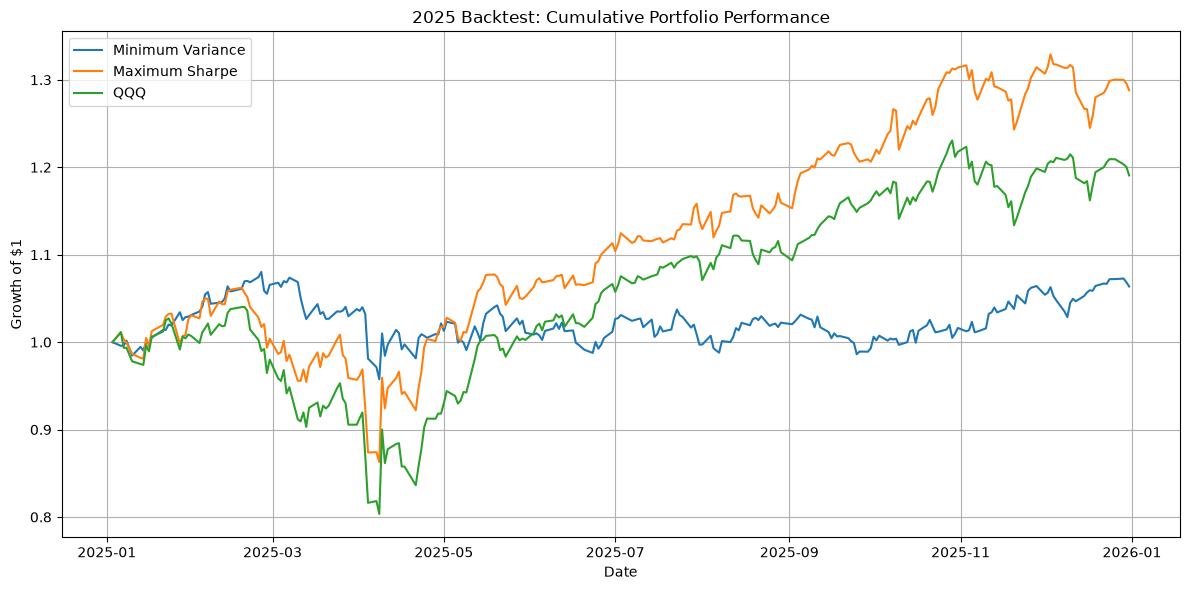

In [94]:
# Step 35: Plot Cumulative Performance

import matplotlib.pyplot as plt

# Normalize all portfolios to 1.0 at the start
normalized_cumulative = (
    cumulative_returns
    / cumulative_returns.iloc[0]
)

plt.figure(figsize=(12, 6))

plt.plot(
    normalized_cumulative.index,
    normalized_cumulative["Minimum Variance"],
    label="Minimum Variance"
)

plt.plot(
    normalized_cumulative.index,
    normalized_cumulative["Maximum Sharpe"],
    label="Maximum Sharpe"
)

plt.plot(
    normalized_cumulative.index,
    normalized_cumulative["QQQ"],
    label="QQQ"
)

plt.title("2025 Backtest: Cumulative Portfolio Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

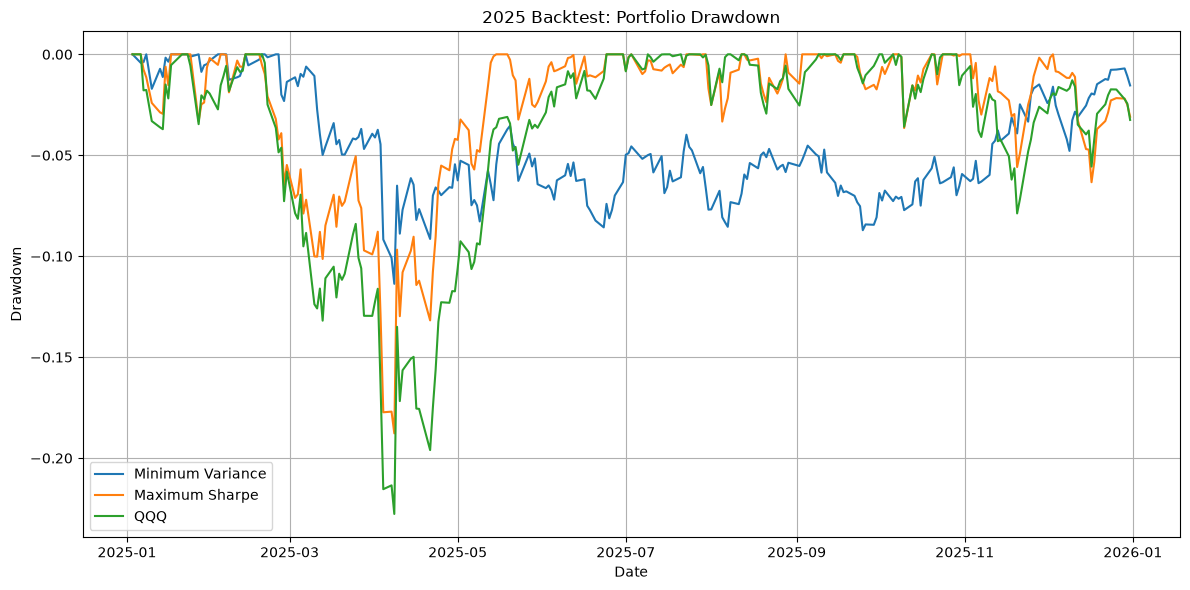

In [95]:
# Step 36: Plot Drawdown

drawdown_df = pd.DataFrame(index=cumulative_returns.index)

for column in cumulative_returns.columns:
    running_max = cumulative_returns[column].cummax()
    drawdown_df[column] = cumulative_returns[column] / running_max - 1

plt.figure(figsize=(12, 6))

plt.plot(
    drawdown_df.index,
    drawdown_df["Minimum Variance"],
    label="Minimum Variance"
)

plt.plot(
    drawdown_df.index,
    drawdown_df["Maximum Sharpe"],
    label="Maximum Sharpe"
)

plt.plot(
    drawdown_df.index,
    drawdown_df["QQQ"],
    label="QQQ"
)

plt.title("2025 Backtest: Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()